In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv
/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv


In [2]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model, Input, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from collections import deque
import random
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import json
import warnings
from datetime import timedelta
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

C = {
    'teal'   : '#00897B',
    'amber'  : '#FF8F00',
    'violet' : '#6A1B9A',
    'rose'   : '#C62828',
    'indigo' : '#283593',
    'lime'   : '#558B2F',
    'slate'  : '#546E7A',
    'gold'   : '#F9A825',
}
CLIST = list(C.values())

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.22,
    'font.family'      : 'DejaVu Sans',
})

os.makedirs('saved_models', exist_ok=True)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f'GPU: {gpus}')
else:
    print('Running on CPU')
print('TensorFlow:', tf.__version__)
print('All imports done')

2026-03-29 07:17:29.174628: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774768649.374418      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774768649.433768      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774768649.907081      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774768649.907125      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774768649.907127      55 computation_placer.cc:177] computation placer alr

Running on CPU
TensorFlow: 2.19.0
All imports done


2026-03-29 07:17:52.978595: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
t0 = time.time()
interaction_data = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/interaction_data.csv')
presentations    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations.csv')
presentations_df = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/presentations_df.csv')
ratings_matrix   = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/ratings_matrix.csv')
recommendations  = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/recommendations.csv')
user_profiles    = pd.read_csv('/kaggle/input/datasets/bh7gy0189/presentation-advisor-data/user_profiles.csv')
print(f'Loaded in {time.time()-t0:.2f}s')
for name, dframe in [('interaction_data', interaction_data),
                      ('ratings_matrix',   ratings_matrix),
                      ('recommendations',  recommendations),
                      ('user_profiles',    user_profiles)]:
    print(f'  {name:<20}: {dframe.shape}')

Loaded in 0.15s
  interaction_data    : (25000, 75)
  ratings_matrix      : (3000, 5)
  recommendations     : (100, 26)
  user_profiles       : (30, 5)


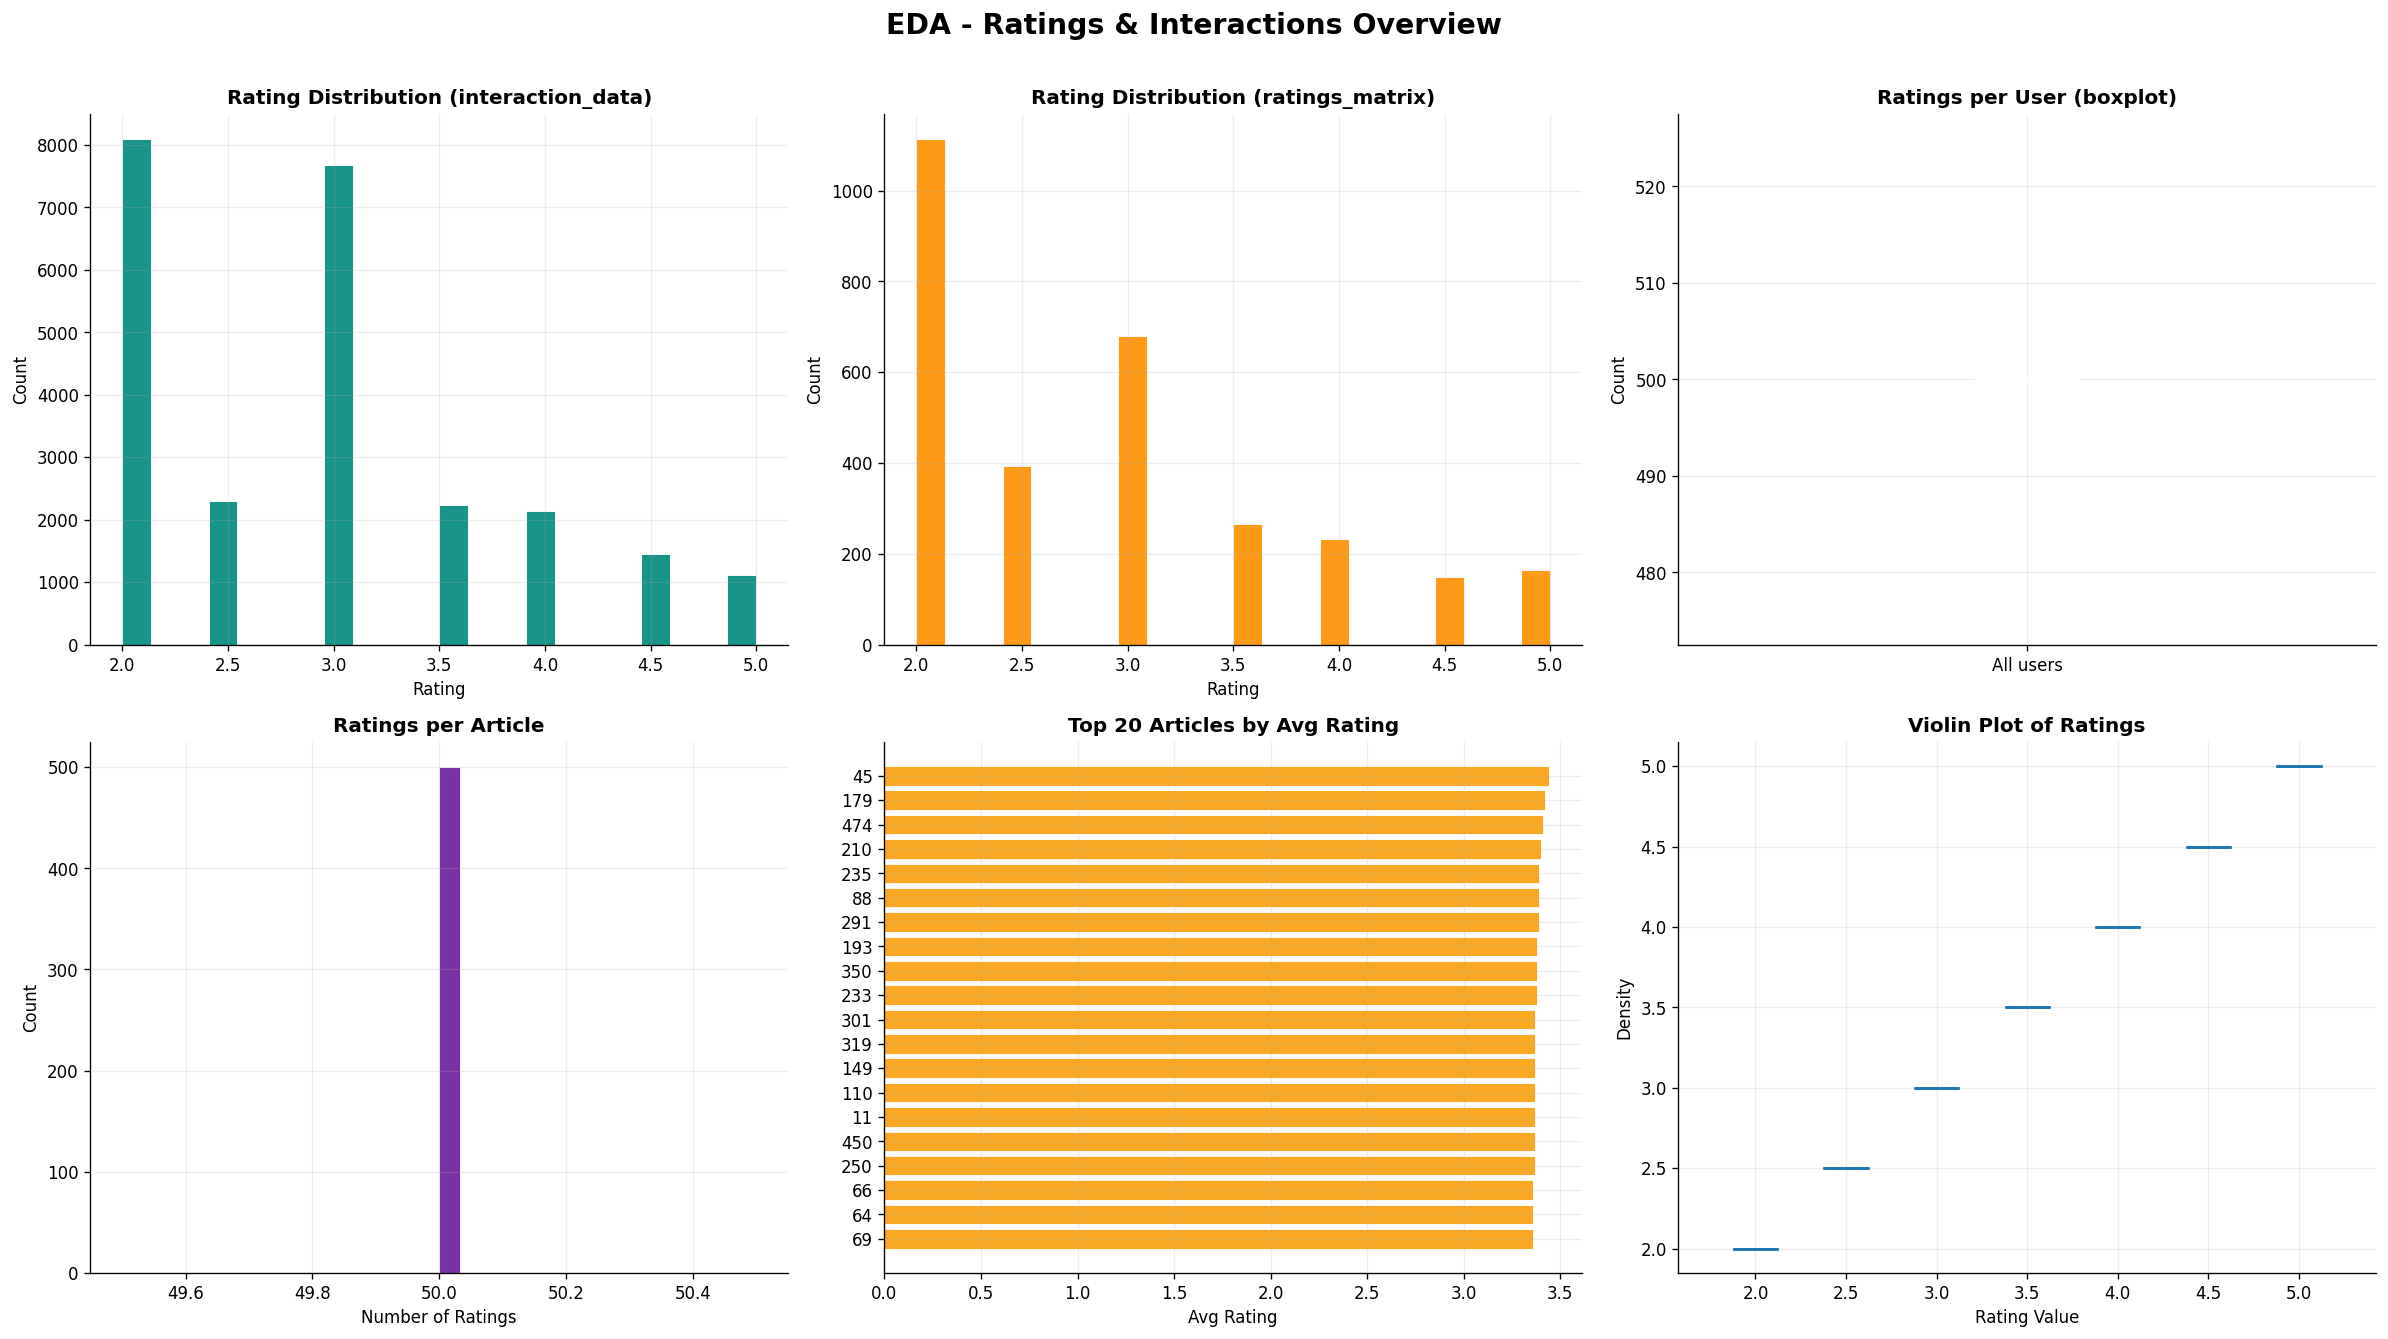

Saved: saved_models/eda_ratings_overview.png


In [5]:
%matplotlib inline
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('EDA - Ratings & Interactions Overview', fontsize=17, fontweight='bold', y=1.01)

axes[0,0].hist(interaction_data['rating'], bins=22,
               color=C['teal'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0,0].set_title('Rating Distribution (interaction_data)', fontweight='bold')
axes[0,0].set_xlabel('Rating'); axes[0,0].set_ylabel('Count')

axes[0,1].hist(ratings_matrix['rating'], bins=22,
               color=C['amber'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[0,1].set_title('Rating Distribution (ratings_matrix)', fontweight='bold')
axes[0,1].set_xlabel('Rating'); axes[0,1].set_ylabel('Count')

ratings_per_user = interaction_data.groupby('user_id')['rating'].count()
axes[0,2].boxplot(ratings_per_user.values, patch_artist=True,
                  boxprops=dict(facecolor=C['lime'], color='white'),
                  medianprops=dict(color='white', linewidth=2.5),
                  whiskerprops=dict(color=C['lime']),
                  capprops=dict(color=C['lime']),
                  flierprops=dict(markerfacecolor=C['rose'], marker='o', markersize=4, alpha=0.5))
axes[0,2].set_title('Ratings per User (boxplot)', fontweight='bold')
axes[0,2].set_ylabel('Count'); axes[0,2].set_xticklabels(['All users'])

ratings_per_article = interaction_data.groupby('article_id')['rating'].count()
axes[1,0].hist(ratings_per_article.values, bins=30,
               color=C['violet'], edgecolor='white', linewidth=0.6, alpha=0.9)
axes[1,0].set_title('Ratings per Article', fontweight='bold')
axes[1,0].set_xlabel('Number of Ratings'); axes[1,0].set_ylabel('Count')

avg_per_article = (interaction_data.groupby('article_id')['rating']
                   .mean().sort_values(ascending=True).tail(20))
axes[1,1].barh(avg_per_article.index.astype(str), avg_per_article.values,
               color=C['gold'], edgecolor='white', linewidth=0.5)
axes[1,1].set_title('Top 20 Articles by Avg Rating', fontweight='bold')
axes[1,1].set_xlabel('Avg Rating')

unique_r  = sorted(interaction_data['rating'].unique())
data_by_r = [interaction_data[interaction_data['rating']==r]['rating'].values for r in unique_r]
vp = axes[1,2].violinplot(data_by_r, positions=unique_r, showmeans=True, showmedians=False)
for i, body in enumerate(vp['bodies']):
    body.set_facecolor(CLIST[i % len(CLIST)]); body.set_alpha(0.75)
axes[1,2].set_title('Violin Plot of Ratings', fontweight='bold')
axes[1,2].set_xlabel('Rating Value'); axes[1,2].set_ylabel('Density')

plt.tight_layout()
plt.savefig('saved_models/eda_ratings_overview.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/eda_ratings_overview.png')

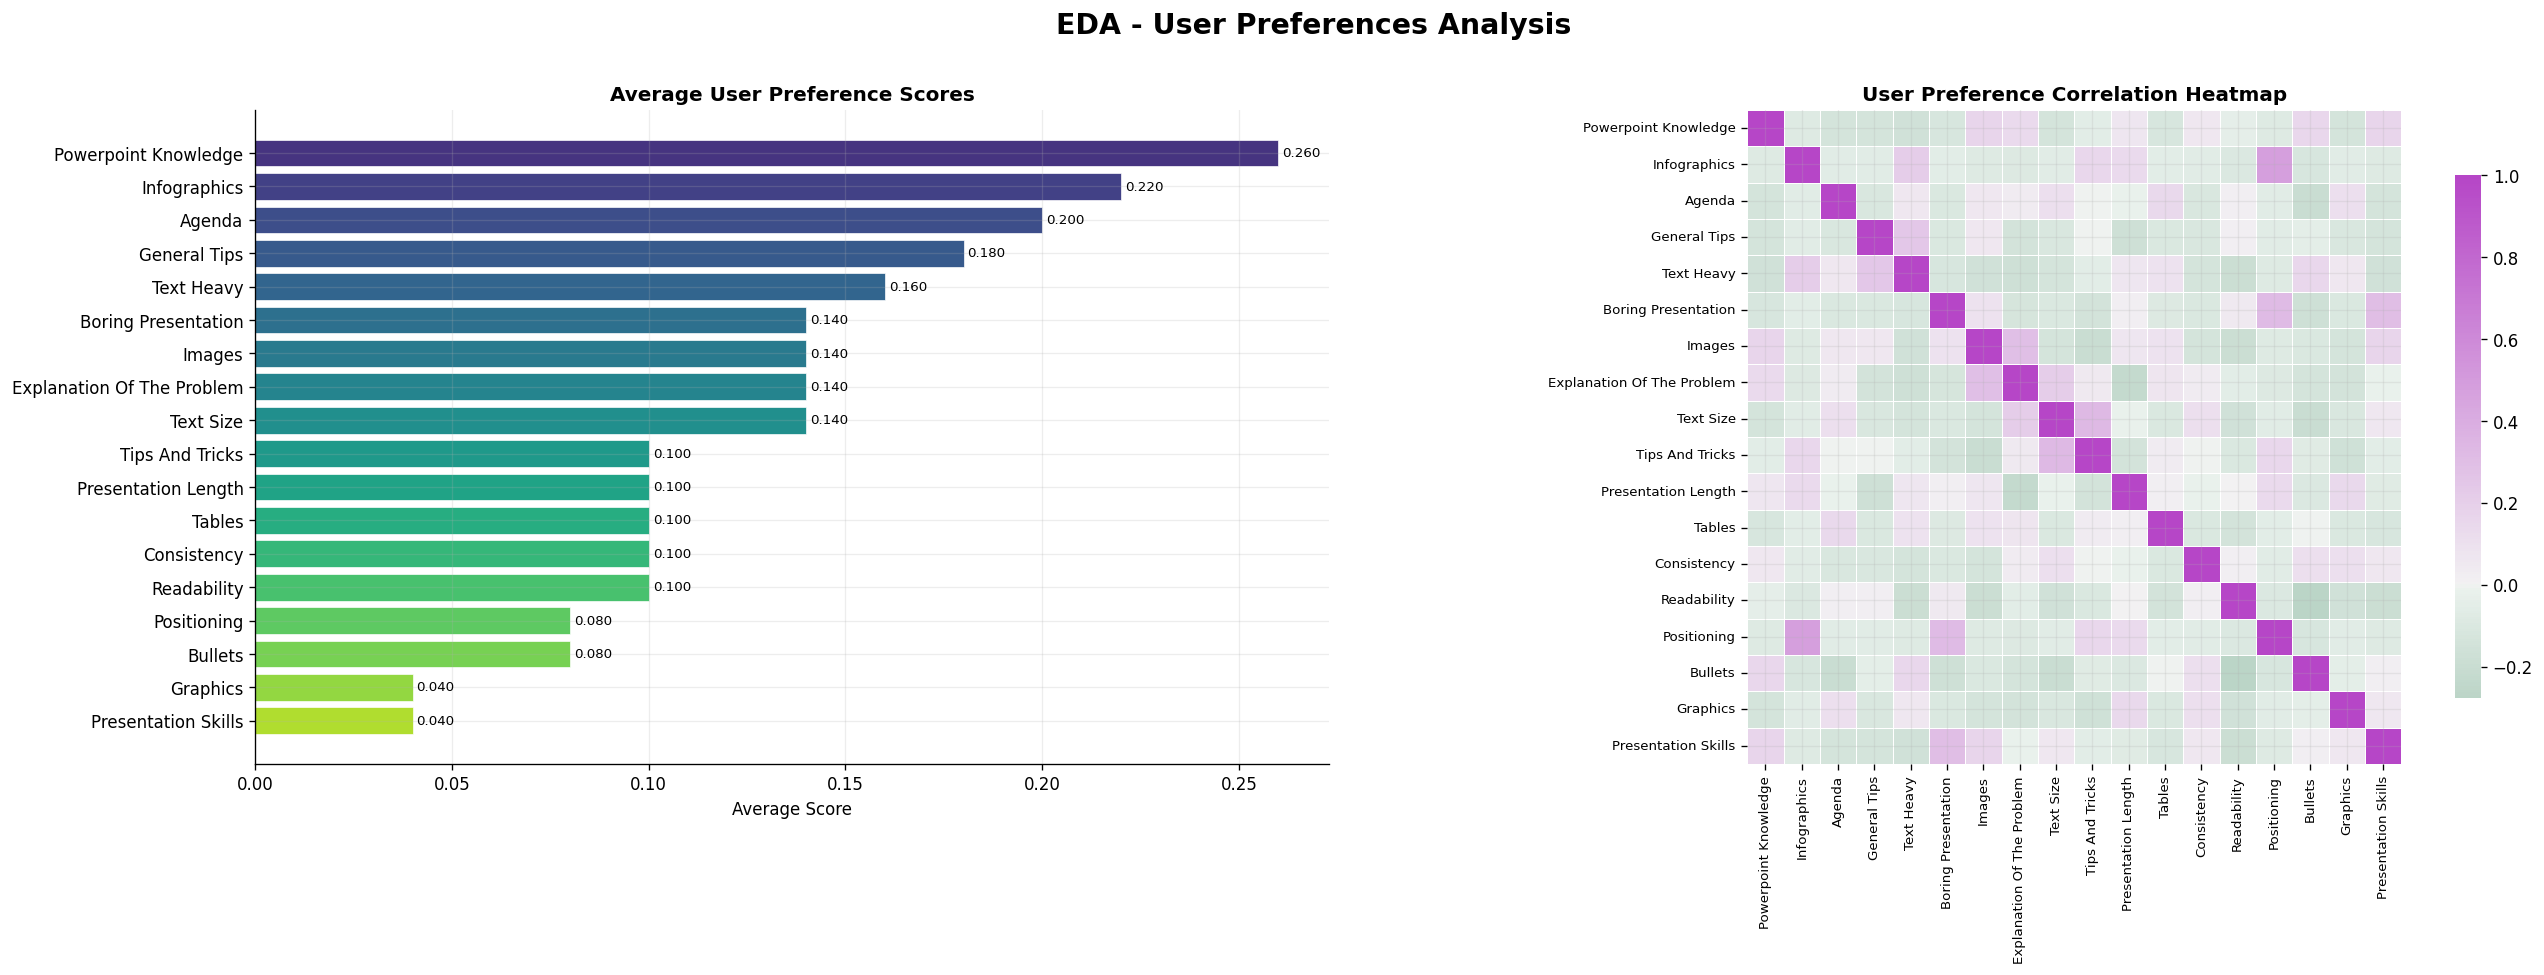

Saved: saved_models/eda_user_preferences.png


In [6]:
pref_cols   = [c for c in interaction_data.columns if c.startswith('user_preference_')]
avg_prefs   = interaction_data[pref_cols].mean().sort_values(ascending=False)
clean_lbl   = [c.replace('user_preference_','').replace('_',' ').title() for c in avg_prefs.index]

fig, axes = plt.subplots(1, 2, figsize=(22, 8))
fig.suptitle('EDA - User Preferences Analysis', fontsize=17, fontweight='bold', y=1.01)

grad = plt.cm.viridis(np.linspace(0.15, 0.88, len(avg_prefs)))
bars = axes[0].barh(clean_lbl, avg_prefs.values, color=grad, edgecolor='white', linewidth=0.4)
axes[0].set_title('Average User Preference Scores', fontweight='bold')
axes[0].set_xlabel('Average Score'); axes[0].invert_yaxis()
for bar, val in zip(bars, avg_prefs.values):
    axes[0].text(val+0.001, bar.get_y()+bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8)

pref_corr = interaction_data[pref_cols].corr()
sns.heatmap(pref_corr, ax=axes[1],
            cmap=sns.diverging_palette(145, 300, as_cmap=True),
            center=0, square=True, linewidths=0.3,
            xticklabels=clean_lbl, yticklabels=clean_lbl,
            cbar_kws={'shrink': 0.8})
axes[1].set_title('User Preference Correlation Heatmap', fontweight='bold')
axes[1].tick_params(axis='x', rotation=90, labelsize=8)
axes[1].tick_params(axis='y', rotation=0,  labelsize=8)

plt.tight_layout()
plt.savefig('saved_models/eda_user_preferences.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/eda_user_preferences.png')

In [7]:
df_merged = interaction_data.copy()
df_merged = df_merged.merge(
    user_profiles[['user_id','type','location','preferences','preferred_presentation_type']],
    on='user_id', how='left', suffixes=('','_user'))
df_merged = df_merged.merge(
    recommendations[['article_id','presentation_type','audience_type','Main issue','popularity']],
    on='article_id', how='left', suffixes=('','_rec'))
print(f'Merged shape: {df_merged.shape}')

Merged shape: (25000, 83)


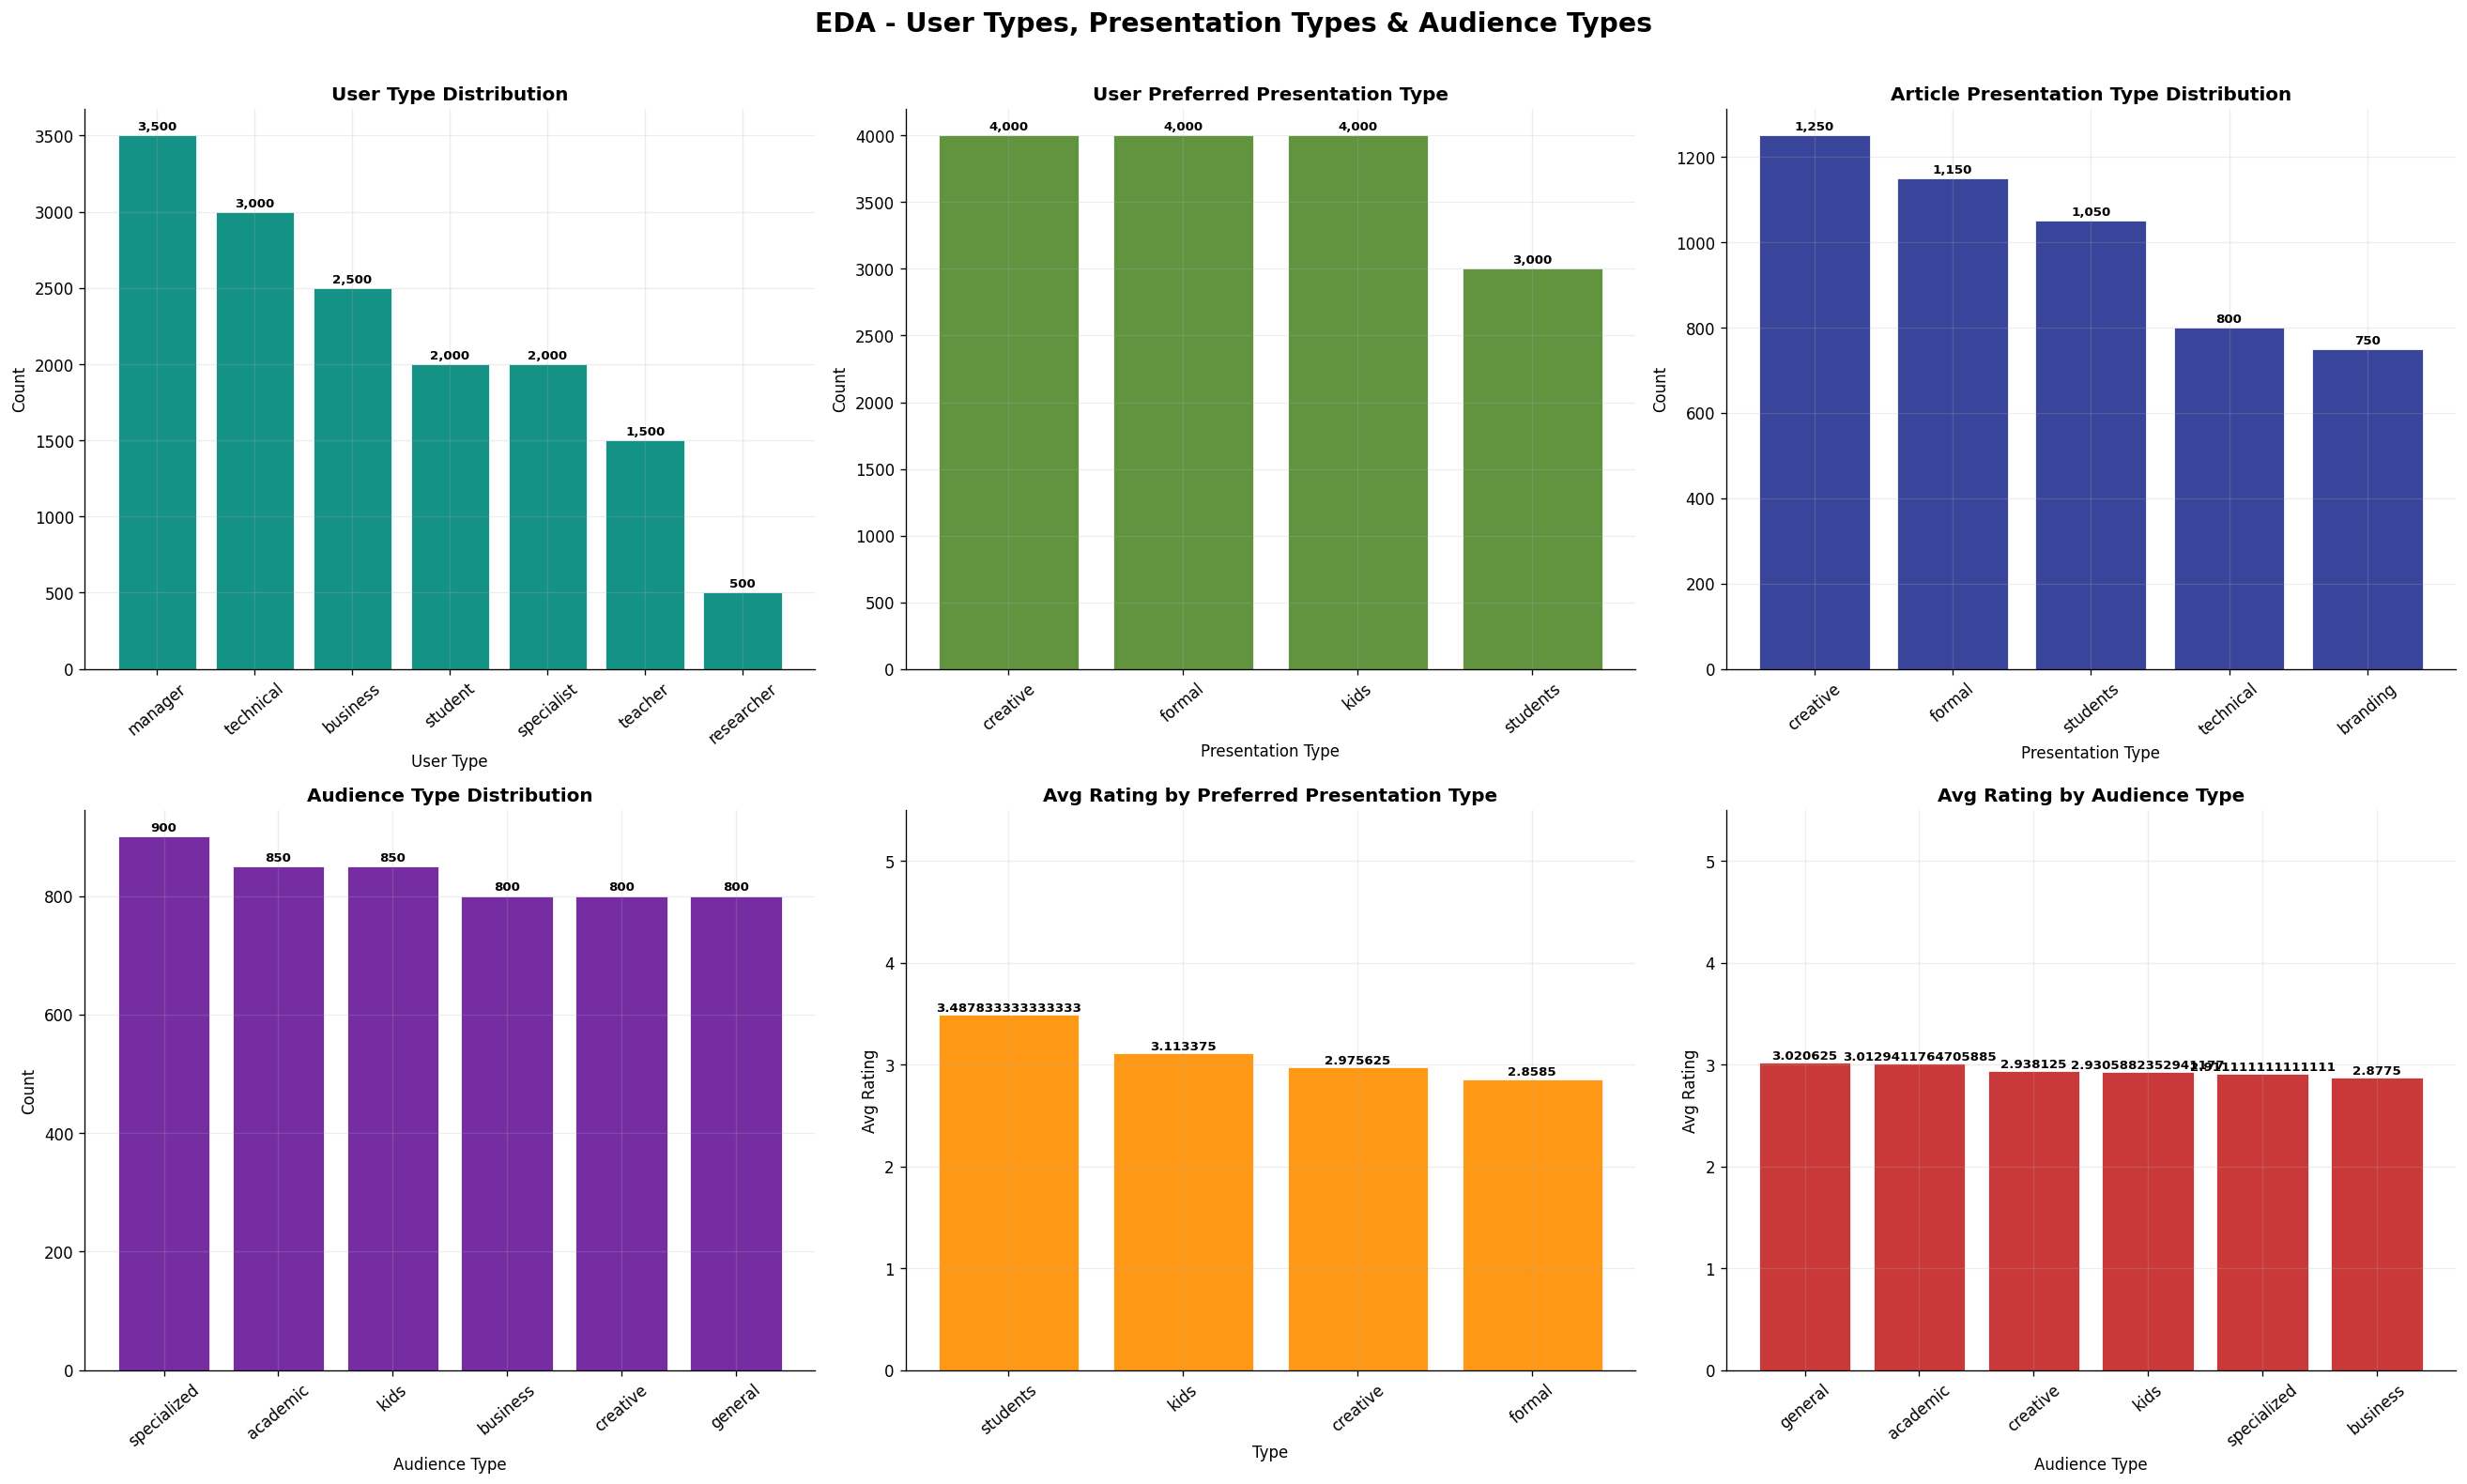

Saved: saved_models/eda_user_presentation_types.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(22, 13))
fig.suptitle('EDA - User Types, Presentation Types & Audience Types', fontsize=17, fontweight='bold', y=1.01)

def annotated_bar(ax, idx, vals, color, title, xl, yl):
    bars = ax.bar(idx, vals, color=color, edgecolor='white', linewidth=0.5, alpha=0.92)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.tick_params(axis='x', rotation=40)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+max(vals)*0.01,
                f'{v:,}', ha='center', fontsize=8, fontweight='bold')

utc = df_merged['type'].value_counts()
annotated_bar(axes[0,0], utc.index, utc.values, C['teal'], 'User Type Distribution','User Type','Count')
ppt = df_merged['preferred_presentation_type'].value_counts()
annotated_bar(axes[0,1], ppt.index, ppt.values, C['lime'], 'User Preferred Presentation Type','Presentation Type','Count')
apt = df_merged['presentation_type'].value_counts()
annotated_bar(axes[0,2], apt.index, apt.values, C['indigo'], 'Article Presentation Type Distribution','Presentation Type','Count')
auc = df_merged['audience_type'].value_counts()
annotated_bar(axes[1,0], auc.index, auc.values, C['violet'], 'Audience Type Distribution','Audience Type','Count')
abp = df_merged.groupby('preferred_presentation_type')['rating'].mean().sort_values(ascending=False)
annotated_bar(axes[1,1], abp.index, abp.values, C['amber'], 'Avg Rating by Preferred Presentation Type','Type','Avg Rating')
axes[1,1].set_ylim(0, 5.5)
aba = df_merged.groupby('audience_type')['rating'].mean().sort_values(ascending=False)
annotated_bar(axes[1,2], aba.index, aba.values, C['rose'], 'Avg Rating by Audience Type','Audience Type','Avg Rating')
axes[1,2].set_ylim(0, 5.5)

plt.tight_layout()
plt.savefig('saved_models/eda_user_presentation_types.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/eda_user_presentation_types.png')

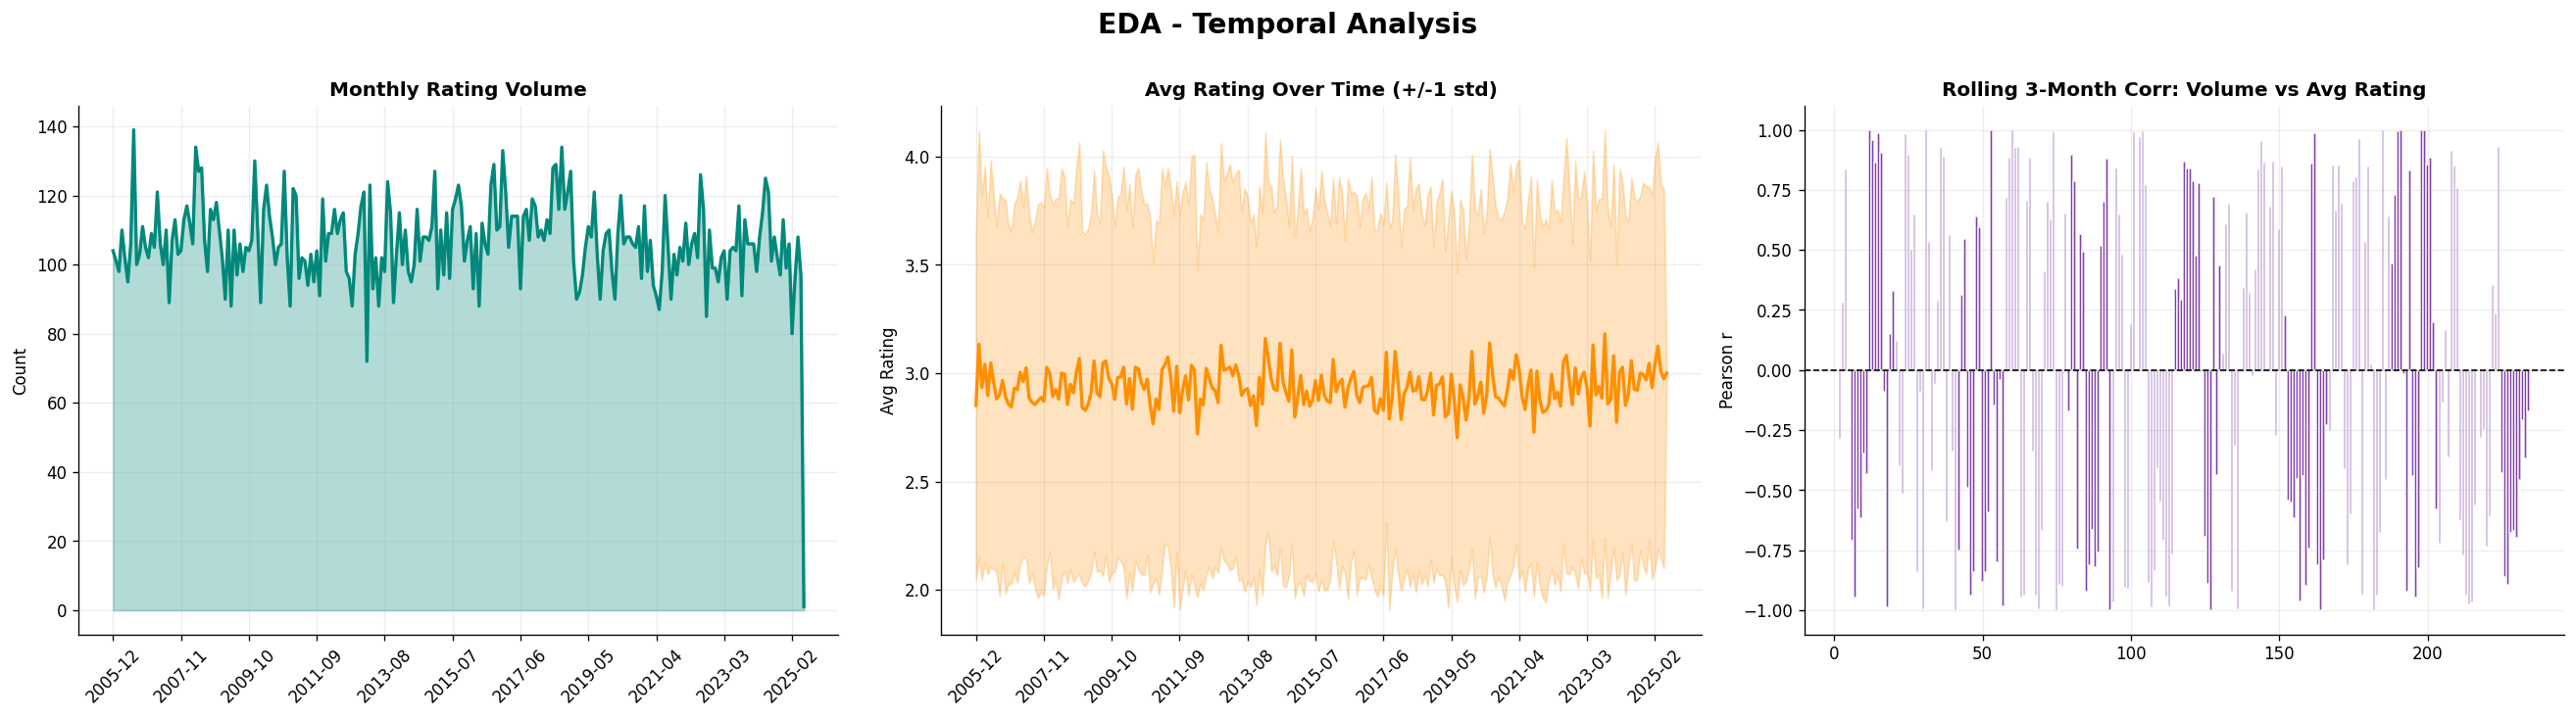

Saved: saved_models/eda_temporal.png


In [9]:
interaction_data['timestamp'] = pd.to_datetime(interaction_data['timestamp'])
ratings_matrix['timestamp']   = pd.to_datetime(ratings_matrix['timestamp'])
interaction_data['year_month'] = interaction_data['timestamp'].dt.to_period('M')
monthly_cnt = interaction_data.groupby('year_month').size()
monthly_avg = interaction_data.groupby('year_month')['rating'].mean()
monthly_std = interaction_data.groupby('year_month')['rating'].std().fillna(0)
x_lbl  = monthly_cnt.index.astype(str)
step_x = max(1, len(x_lbl)//10)

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('EDA - Temporal Analysis', fontsize=17, fontweight='bold', y=1.01)

axes[0].fill_between(range(len(x_lbl)), monthly_cnt.values, color=C['teal'], alpha=0.3)
axes[0].plot(range(len(x_lbl)), monthly_cnt.values, color=C['teal'], linewidth=2)
axes[0].set_xticks(range(0, len(x_lbl), step_x))
axes[0].set_xticklabels(x_lbl[::step_x], rotation=45)
axes[0].set_title('Monthly Rating Volume', fontweight='bold'); axes[0].set_ylabel('Count')

axes[1].fill_between(range(len(x_lbl)),
                      monthly_avg.values - monthly_std.values,
                      monthly_avg.values + monthly_std.values,
                      color=C['amber'], alpha=0.25)
axes[1].plot(range(len(x_lbl)), monthly_avg.values, color=C['amber'], linewidth=2)
axes[1].set_xticks(range(0, len(x_lbl), step_x))
axes[1].set_xticklabels(x_lbl[::step_x], rotation=45)
axes[1].set_title('Avg Rating Over Time (+/-1 std)', fontweight='bold'); axes[1].set_ylabel('Avg Rating')

roll_corr = pd.Series(monthly_avg.values).rolling(3).corr(pd.Series(monthly_cnt.values))
axes[2].bar(range(len(roll_corr)), roll_corr.values, color=C['violet'], edgecolor='white', alpha=0.85)
axes[2].axhline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_title('Rolling 3-Month Corr: Volume vs Avg Rating', fontweight='bold')
axes[2].set_ylabel('Pearson r')

plt.tight_layout()
plt.savefig('saved_models/eda_temporal.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/eda_temporal.png')

In [10]:
print('Starting Feature Engineering...')
df = interaction_data.copy()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour']      = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df['month']     = df['timestamp'].dt.month
df['hour_sin']  = np.sin(2*np.pi*df['hour']/24)
df['hour_cos']  = np.cos(2*np.pi*df['hour']/24)
df['day_sin']   = np.sin(2*np.pi*df['dayofweek']/7)
df['day_cos']   = np.cos(2*np.pi*df['dayofweek']/7)
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)
df = df.sort_values('timestamp')
first_ts = df.groupby('user_id')['timestamp'].transform('min')
df['days_since_first'] = (df['timestamp'] - first_ts).dt.days
user_stats = df.groupby('user_id').agg(
    user_avg_rating=('rating','mean'),
    user_rating_count=('rating','count'),
    user_rating_std=('rating','std')).reset_index()
user_stats['user_rating_std'] = user_stats['user_rating_std'].fillna(0)
df = df.merge(user_stats, on='user_id', how='left')
item_stats = df.groupby('article_id').agg(
    item_avg_rating=('rating','mean'),
    item_rating_count=('rating','count'),
    item_rating_std=('rating','std')).reset_index()
item_stats['item_rating_std'] = item_stats['item_rating_std'].fillna(0)
df = df.merge(item_stats, on='article_id', how='left')
pref_cols_fe  = [c for c in df.columns if c.startswith('user_preference_')]
issue_cols_fe = ['Boring presentation','Graphics','Readability','Consistency',
                 'Images','Bullets','Text size','Text heavy','Tables',
                 'Agenda','Infographics','Positioning']
def compute_match(row):
    return sum(int(row[p]==row[i]) for p,i in zip(pref_cols_fe, issue_cols_fe) if i in row.index)
tqdm.pandas(desc='Computing match scores')
df['preference_match_score'] = df.progress_apply(compute_match, axis=1)
df['time_decay_weight'] = np.exp(-0.005 * df['days_since_first'])  # improved: 0.005 vs 0.01
scaler     = MinMaxScaler()
scale_cols = ['days_since_first','user_avg_rating','user_rating_count','user_rating_std',
              'item_avg_rating','item_rating_count','item_rating_std',
              'preference_match_score','time_decay_weight']
df[scale_cols] = scaler.fit_transform(df[scale_cols])
print(f'Feature engineering done. Shape: {df.shape}')

Starting Feature Engineering...


Computing match scores: 100%|██████████| 25000/25000 [00:00<00:00, 25204.15it/s]

Feature engineering done. Shape: (25000, 94)


In [11]:
print('='*65)
print('  MODEL 3 (IMPROVED): DUELING DQN + DOUBLE DQN + PER')
print('='*65)
print('  Improvements over original DQN:')
print('  - Dueling architecture: separate Value + Advantage streams')
print('  - Double DQN target: reduces Q-value overestimation bias')
print('  - Prioritised Experience Replay (PER) instead of uniform')
print('  - Huber loss: robust to outlier rewards')
print('  - L2 regularisation on all dense layers')
print('  - Reward shaping: preference-match bonus')
print('  - More episodes (5 vs 3), larger buffer (5000 vs 2000)')
print('  - Faster target sync every 50 steps (was 100)')
print('  - Higher gamma 0.97 (was 0.95)')
print('='*65)

USER_FEAT_COLS = [
    'user_preference_Boring presentation','user_preference_Graphics',
    'user_preference_Readability','user_preference_Consistency',
    'user_preference_Images','user_preference_Bullets',
    'user_preference_Text size','user_preference_Text heavy',
    'user_preference_Tables','user_preference_Agenda',
    'user_preference_Infographics','user_preference_Positioning',
    'user_preference_Presentation length','user_preference_General tips',
    'user_preference_Presentation skills','user_preference_Powerpoint knowledge',
    'user_preference_tips and tricks','user_preference_Explanation of the problem',
    'user_type_business','user_type_teacher','user_type_student',
    'user_type_researcher','user_type_manager','user_type_technical','user_type_specialist',
    'presentation_type_formal_x','presentation_type_creative_x',
    'presentation_type_business_x','presentation_type_educational_x',
    'presentation_type_technical_x','presentation_type_persuasive_x'
]
ITEM_FEAT_COLS = [
    'Boring presentation','Graphics','Readability','Consistency',
    'Images','Bullets','Text size','Text heavy','Tables','Agenda',
    'Infographics','Positioning','Presentation length','General tips',
    'Presentation skills','Powerpoint knowledge','tips and tricks',
    'Explanation of the problem',
    'presentation_type_formal_y','presentation_type_creative_y',
    'presentation_type_business_y','presentation_type_educational_y',
    'presentation_type_technical_y','presentation_type_persuasive_y',
    'audience_type_academic','audience_type_business','audience_type_technical',
    'audience_type_kids','audience_type_general'
]
USER_FEAT_COLS = [c for c in USER_FEAT_COLS if c in interaction_data.columns]
ITEM_FEAT_COLS = [c for c in ITEM_FEAT_COLS if c in interaction_data.columns]
print(f'User feature dim : {len(USER_FEAT_COLS)}')
print(f'Item feature dim : {len(ITEM_FEAT_COLS)}')

  MODEL 3 (IMPROVED): DUELING DQN + DOUBLE DQN + PER
  Improvements over original DQN:
  - Dueling architecture: separate Value + Advantage streams
  - Double DQN target: reduces Q-value overestimation bias
  - Prioritised Experience Replay (PER) instead of uniform
  - Huber loss: robust to outlier rewards
  - L2 regularisation on all dense layers
  - Reward shaping: preference-match bonus
  - More episodes (5 vs 3), larger buffer (5000 vs 2000)
  - Faster target sync every 50 steps (was 100)
  - Higher gamma 0.97 (was 0.95)
User feature dim : 31
Item feature dim : 29


In [12]:
df_dqn  = interaction_data.copy()
keep    = ['user_id','article_id','rating'] + USER_FEAT_COLS + ITEM_FEAT_COLS
keep    = [c for c in keep if c in df_dqn.columns]
df_dqn  = df_dqn[keep].dropna()
for c in ITEM_FEAT_COLS:
    if c not in df_dqn.columns:
        df_dqn[c] = 0
article_features_dqn = df_dqn.groupby('article_id')[ITEM_FEAT_COLS].first().reset_index()
article_ids          = article_features_dqn['article_id'].values
n_actions            = len(article_ids)
article_feat_matrix  = article_features_dqn[ITEM_FEAT_COLS].values.astype(np.float32)
art2idx               = {aid: i for i, aid in enumerate(article_ids)}
df_dqn['article_idx'] = df_dqn['article_id'].map(art2idx)
STATE_DIM  = len(USER_FEAT_COLS) + len(ITEM_FEAT_COLS)
ACTION_DIM = n_actions
train_dqn, temp_dqn = train_test_split(df_dqn, test_size=0.30, random_state=SEED)
val_dqn,   test_dqn = train_test_split(temp_dqn, test_size=0.50, random_state=SEED)
print(f'Train: {len(train_dqn)} | Val: {len(val_dqn)} | Test: {len(test_dqn)}')
print(f'State dim: {STATE_DIM} | Action dim: {ACTION_DIM}')

Train: 17500 | Val: 3750 | Test: 3750
State dim: 60 | Action dim: 500


In [13]:
def build_dueling_dqn(state_dim, action_dim,
                       shared_units=256, branch_units=128,
                       dropout_rate=0.25, l2_reg=1e-4, lr=5e-4):
    """
    Dueling DQN architecture.
    Q(s,a) = V(s) + A(s,a) - mean(A(s,.))
    Separates state value from action advantage, reducing overestimation.
    """
    inp = Input(shape=(state_dim,), name='state')
    # Shared encoder
    x = layers.Dense(shared_units, activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg),
                      name='shared1')(inp)
    x = layers.BatchNormalization(name='bn_shared1')(x)
    x = layers.Dropout(dropout_rate, name='drop_shared1')(x)
    x = layers.Dense(shared_units // 2, activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg),
                      name='shared2')(x)
    x = layers.BatchNormalization(name='bn_shared2')(x)
    x = layers.Dropout(dropout_rate, name='drop_shared2')(x)
    # Value stream
    v = layers.Dense(branch_units, activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg), name='val_dense')(x)
    v = layers.Dense(1, activation='linear', name='val_out')(v)
    # Advantage stream
    a = layers.Dense(branch_units, activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg), name='adv_dense')(x)
    a = layers.Dense(action_dim, activation='linear', name='adv_out')(a)
    # Combine
    a_mean = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1, keepdims=True),
                            name='adv_mean')(a)
    q = layers.Add(name='q_values')([v, layers.Subtract()([a, a_mean])])
    model = Model(inp, q, name='DuelingDQN')
    model.compile(
        optimizer=tf.keras.optimizers.Adam(lr, clipnorm=1.0),
        loss=tf.keras.losses.Huber(delta=1.0))
    return model

dqn_online = build_dueling_dqn(STATE_DIM, ACTION_DIM)
dqn_target = build_dueling_dqn(STATE_DIM, ACTION_DIM)
dqn_target.set_weights(dqn_online.get_weights())
dqn_online.summary()
print(f'Parameters: {dqn_online.count_params():,}')

Model: "DuelingDQN"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ state (InputLayer)  │ (None, 60)        │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared1 (Dense)     │ (None, 256)       │     15,616 │ state[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared1          │ (None, 256)       │      1,024 │ shared1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_shared1        │ (None, 256)       │          0 │ bn_shared1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared2 (Dense)     │ (None, 128)       │     32,896 │ drop_shared1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_shared2          │ (None, 128)       │        512 │ shared2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ drop_shared2        │ (None, 128)       │          0 │ bn_shared2[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_dense (Dense)   │ (None, 128)       │     16,512 │ drop_shared2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_out (Dense)     │ (None, 500)       │     64,500 │ adv_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ val_dense (Dense)   │ (None, 128)       │     16,512 │ drop_shared2[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ adv_mean (Lambda)   │ (None, 1)         │          0 │ adv_out[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ val_out (Dense)     │ (None, 1)         │        129 │ val_dense[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ subtract (Subtract) │ (None, 500)       │          0 │ adv_out[0][0],    │
│                     │                   │            │ adv_mean[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ q_values (Add)      │ (None, 500)       │          0 │ val_out[0][0],    │
│                     │                   │            │ subtract[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,701 (576.96 KB)

 Trainable params: 146,933 (573.96 KB)

 Non-trainable params: 768 (3.00 KB)

Parameters: 147,701


In [14]:
class PrioritisedReplayBuffer:
    """Priority-based replay: samples high-TD-error transitions more often."""
    def __init__(self, capacity, alpha=0.6, beta_start=0.4):
        self.capacity = capacity; self.alpha = alpha
        self.beta = beta_start; self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.pos = 0
    def add(self, transition, td_error=1.0):
        p = (abs(td_error) + 1e-5) ** self.alpha
        if len(self.buffer) < self.capacity:
            self.buffer.append(transition)
        else:
            self.buffer[self.pos] = transition
        self.priorities[self.pos] = p
        self.pos = (self.pos + 1) % self.capacity
    def sample(self, batch_size, total_steps):
        n = len(self.buffer)
        probs = self.priorities[:n] ** self.alpha
        probs /= probs.sum()
        idxs  = np.random.choice(n, batch_size, p=probs, replace=False)
        self.beta = min(1.0, self.beta + (1.0 - 0.4) / max(1, total_steps))
        weights = (n * probs[idxs]) ** (-self.beta)
        weights /= weights.max()
        return [self.buffer[i] for i in idxs], idxs, weights.astype(np.float32)
    def update_priorities(self, idxs, td_errors):
        for i, e in zip(idxs, td_errors):
            self.priorities[i] = (abs(e) + 1e-5) ** self.alpha
    def __len__(self): return len(self.buffer)

print('PrioritisedReplayBuffer ready')

PrioritisedReplayBuffer ready


In [15]:
# ── IMPROVED HYPERPARAMETERS ──────────────────────────────────────────
# original -> improved
# EPISODES:      3  -> 5     | GAMMA:        0.95 -> 0.97
# REPLAY_SIZE: 2000 -> 5000  | BATCH_SIZE:    128 -> 64
# TARGET_UPDATE: 100-> 50    | EPSILON_DECAY:0.995-> 0.997
# Loss: MSE -> Huber         | Arch: Vanilla -> Dueling
# Replay: Uniform -> PER     | Target: Standard -> Double DQN
# ─────────────────────────────────────────────────────────────────────
GAMMA         = 0.97
EPSILON       = 1.0
EPSILON_MIN   = 0.05
EPSILON_DECAY = 0.997
BATCH_SIZE    = 64
TARGET_UPDATE = 50
EPISODES      = 5
REPLAY_SIZE   = 5000
MIN_REPLAY    = 512
STEPS_PER_EP  = min(3000, len(train_dqn))
PREF_BONUS    = 0.15

per_buffer = PrioritisedReplayBuffer(REPLAY_SIZE, alpha=0.6, beta_start=0.4)

if 'preference_match_score' in df_dqn.columns:
    pref_lookup = df_dqn.set_index(['user_id','article_id'])['preference_match_score'].to_dict()
else:
    pref_lookup = {}

def get_state(user_feats, article_idx):
    return np.concatenate([user_feats, article_feat_matrix[article_idx]]).astype(np.float32)

def choose_action(state, eps):
    if np.random.rand() < eps:
        return np.random.randint(ACTION_DIM)
    return int(np.argmax(dqn_online(state[np.newaxis,:], training=False).numpy()[0]))

@tf.function
def train_step_per(states, targets, weights):
    with tf.GradientTape() as tape:
        preds     = dqn_online(states, training=True)
        elem_loss = tf.keras.losses.Huber(reduction='none', delta=1.0)(targets, preds)
        loss      = tf.reduce_mean(elem_loss * weights)
    grads = tape.gradient(loss, dqn_online.trainable_variables)
    dqn_online.optimizer.apply_gradients(zip(grads, dqn_online.trainable_variables))
    return loss

episode_rewards = []; episode_avg_loss = []; all_losses = []
epsilon_history = []; val_mae_history  = []
step = 0; t_start = time.time()

print(f'IMPROVED DQN  |  Episodes={EPISODES}  |  Gamma={GAMMA}  |  Buffer=PER({REPLAY_SIZE})')
print(f'Batch={BATCH_SIZE}  |  TargetSync={TARGET_UPDATE}  |  EpsDecay={EPSILON_DECAY}')

for ep in range(EPISODES):
    ep_reward = 0.0; ep_losses = []
    ep_data   = train_dqn.sample(STEPS_PER_EP, random_state=ep).reset_index(drop=True)

    for i in tqdm(range(STEPS_PER_EP), desc=f'Ep {ep+1}/{EPISODES}', ncols=85):
        row        = ep_data.iloc[i]
        user_feats = row[USER_FEAT_COLS].values.astype(np.float32)
        true_art   = int(row['article_idx']) if pd.notna(row['article_idx']) else 0
        raw_r      = float(row['rating'])
        state      = get_state(user_feats, true_art)
        action     = choose_action(state, EPSILON)
        base_r     = (raw_r - 3.5) / 1.5
        pref_b     = float(pref_lookup.get((row['user_id'], row['article_id']), 0.0))
        reward     = base_r + PREF_BONUS * pref_b
        next_art   = min(true_art + 1, ACTION_DIM - 1)
        next_state = get_state(user_feats, next_art)
        done       = (i == STEPS_PER_EP - 1)
        per_buffer.add((state, action, reward, next_state, done))
        ep_reward += raw_r; step += 1

        if len(per_buffer) >= MIN_REPLAY:
            batch, idxs, isw = per_buffer.sample(BATCH_SIZE, step)
            s_b  = np.array([x[0] for x in batch], dtype=np.float32)
            a_b  = np.array([x[1] for x in batch], dtype=np.int32)
            r_b  = np.array([x[2] for x in batch], dtype=np.float32)
            ns_b = np.array([x[3] for x in batch], dtype=np.float32)
            d_b  = np.array([x[4] for x in batch], dtype=np.float32)
            # Double DQN: select action with online net, evaluate with target net
            online_next = dqn_online(ns_b, training=False).numpy()
            best_acts   = np.argmax(online_next, axis=1)
            target_next = dqn_target(ns_b, training=False).numpy()
            tgt_np      = dqn_online(s_b, training=False).numpy()
            for j in range(BATCH_SIZE):
                td = (r_b[j] if d_b[j] else r_b[j] + GAMMA * target_next[j, best_acts[j]])
                tgt_np[j, a_b[j]] = td
            loss_v = train_step_per(tf.constant(s_b), tf.constant(tgt_np), tf.constant(isw))
            td_err = np.abs(tgt_np[np.arange(BATCH_SIZE), a_b]
                            - dqn_online(s_b, training=False).numpy()[np.arange(BATCH_SIZE), a_b])
            per_buffer.update_priorities(idxs, td_err)
            all_losses.append(float(loss_v)); ep_losses.append(float(loss_v))
            if EPSILON > EPSILON_MIN:
                EPSILON = max(EPSILON_MIN, EPSILON * EPSILON_DECAY)
        epsilon_history.append(EPSILON)
        if step % TARGET_UPDATE == 0:
            dqn_target.set_weights(dqn_online.get_weights())

    # Validation MAE
    vsamp = val_dqn.sample(min(300, len(val_dqn)), random_state=ep)
    vt, vp_list = [], []
    for _, vr in vsamp.iterrows():
        vu = vr[USER_FEAT_COLS].values.astype(np.float32)
        va = int(vr['article_idx']) if pd.notna(vr['article_idx']) else 0
        vq = dqn_online(get_state(vu, va)[np.newaxis,:], training=False).numpy()[0]
        vmn, vmx = vq.min(), vq.max()
        vpr = 2.0 + (vq[va]-vmn)/(vmx-vmn+1e-8)*3.0 if vmx > vmn else 3.5
        vt.append(float(vr['rating'])); vp_list.append(float(np.clip(vpr,2,5)))
    val_mae = mean_absolute_error(vt, vp_list)
    val_mae_history.append(val_mae)
    avg_loss = np.mean(ep_losses) if ep_losses else 0.0
    episode_rewards.append(ep_reward); episode_avg_loss.append(avg_loss)
    print(f'Ep {ep+1}/{EPISODES} | Reward: {ep_reward:.1f} | Loss: {avg_loss:.4f} | Val MAE: {val_mae:.4f} | Eps: {EPSILON:.4f}')

training_time_dqn = time.time() - t_start
print(f'Total training time: {str(timedelta(seconds=int(training_time_dqn)))}')

IMPROVED DQN  |  Episodes=5  |  Gamma=0.97  |  Buffer=PER(5000)
Batch=64  |  TargetSync=50  |  EpsDecay=0.997


Ep 1/5: 100%|████████████████████████████████████| 3000/3000 [02:16<00:00, 22.00it/s]


Ep 1/5 | Reward: 8809.5 | Loss: 35.9631 | Val MAE: 1.5264 | Eps: 0.0500


Ep 2/5: 100%|████████████████████████████████████| 3000/3000 [02:43<00:00, 18.31it/s]


Ep 2/5 | Reward: 8763.5 | Loss: 56.6317 | Val MAE: 1.4342 | Eps: 0.0500


...

Ep 3/5 | Reward: 8871.5 | Loss: 45.0494 | Val MAE: 1.6114 | Eps: 0.0500


Ep 4/5: 100%|████████████████████████████████████| 3000/3000 [02:46<00:00, 18.05it/s]


Ep 4/5 | Reward: 8864.0 | Loss: 16.3016 | Val MAE: 1.4429 | Eps: 0.0500


Ep 5/5: 100%|████████████████████████████████████| 3000/3000 [02:49<00:00, 17.71it/s]


Ep 5/5 | Reward: 8832.0 | Loss: 15.3274 | Val MAE: 1.3543 | Eps: 0.0500
Total training time: 0:13:35


In [16]:
print('Evaluating on test set...')
y_true_dqn, y_pred_dqn, q_spread_list = [], [], []
test_rows = test_dqn.reset_index(drop=True)
for idx in tqdm(range(len(test_rows)), desc='Evaluating'):
    row        = test_rows.iloc[idx]
    user_feats = row[USER_FEAT_COLS].values.astype(np.float32)
    true_r     = float(row['rating'])
    true_art   = int(row['article_idx']) if pd.notna(row['article_idx']) else 0
    state      = get_state(user_feats, true_art)
    q_vals     = dqn_online(state[np.newaxis,:], training=False).numpy()[0]
    q_mn = q_vals.min(); q_mx = q_vals.max()
    q_spread_list.append(q_mx - q_mn)
    sp_q   = q_vals[true_art]
    pred_r = (2.0 + (sp_q-q_mn)/(q_mx-q_mn+1e-8)*3.0 if q_mx-q_mn > 1e-8 else 3.5)
    y_true_dqn.append(true_r)
    y_pred_dqn.append(float(np.clip(pred_r, 2.0, 5.0)))

y_true_dqn = np.array(y_true_dqn); y_pred_dqn = np.array(y_pred_dqn)
mae_dqn  = mean_absolute_error(y_true_dqn, y_pred_dqn)
mse_dqn  = mean_squared_error(y_true_dqn, y_pred_dqn)
rmse_dqn = np.sqrt(mse_dqn)

print('\n' + '='*65)
print('  MODEL 3 (IMPROVED DQN) - FINAL TEST RESULTS')
print('='*65)
print(f'  MAE  : {mae_dqn:.4f}   (paper: 3.22)')
print(f'  MSE  : {mse_dqn:.4f}  (paper: 12.22)')
print(f'  RMSE : {rmse_dqn:.4f}   (paper: 3.49)')
print(f'  Time : {str(timedelta(seconds=int(training_time_dqn)))}')
print(f'  Beats paper? {"YES" if mae_dqn < 3.22 else "NO"}')
print('='*65)

Evaluating on test set...


Evaluating: 100%|██████████| 3750/3750 [00:37<00:00, 101.01it/s]


  MODEL 3 (IMPROVED DQN) - FINAL TEST RESULTS
  MAE  : 1.3448   (paper: 3.22)
  MSE  : 2.6515  (paper: 12.22)
  RMSE : 1.6283   (paper: 3.49)
  Time : 0:13:35
  Beats paper? YES


In [17]:
dqn_online.save('saved_models/dqn_improved_model.keras')
metrics_out = {
    'model'             : 'Dueling DQN + Double DQN + PER',
    'MAE'               : round(float(mae_dqn), 4),
    'MSE'               : round(float(mse_dqn), 4),
    'RMSE'              : round(float(rmse_dqn), 4),
    'training_time'     : str(timedelta(seconds=int(training_time_dqn))),
    'total_steps'       : step,
    'final_epsilon'     : round(EPSILON, 4),
    'avg_reward_per_ep' : round(float(np.mean(episode_rewards)), 4),
    'val_mae_per_ep'    : [round(v,4) for v in val_mae_history],
    'hyperparams'       : {'GAMMA':GAMMA,'EPSILON_DECAY':EPSILON_DECAY,
                           'BATCH_SIZE':BATCH_SIZE,'TARGET_UPDATE':TARGET_UPDATE,
                           'EPISODES':EPISODES,'REPLAY_SIZE':REPLAY_SIZE,
                           'arch':'DuelingDQN','loss':'Huber','replay':'PER'},
    'paper_MAE'    : 3.22,
    'beats_paper'  : bool(mae_dqn < 3.22)
}
with open('saved_models/dqn_improved_metrics.json','w') as f:
    json.dump(metrics_out, f, indent=2)
print('Saved model and metrics')
print(json.dumps(metrics_out, indent=2))

Saved model and metrics
{
  "model": "Dueling DQN + Double DQN + PER",
  "MAE": 1.3448,
  "MSE": 2.6515,
  "RMSE": 1.6283,
  "training_time": "0:13:35",
  "total_steps": 15000,
  "final_epsilon": 0.05,
  "avg_reward_per_ep": 8828.1,
  "val_mae_per_ep": [
    1.5264,
    1.4342,
    1.6114,
    1.4429,
    1.3543
  ],
  "hyperparams": {
    "GAMMA": 0.97,
    "EPSILON_DECAY": 0.997,
    "BATCH_SIZE": 64,
    "TARGET_UPDATE": 50,
    "EPISODES": 5,
    "REPLAY_SIZE": 5000,
    "arch": "DuelingDQN",
    "loss": "Huber",
    "replay": "PER"
  },
  "paper_MAE": 3.22,
  "beats_paper": true
}


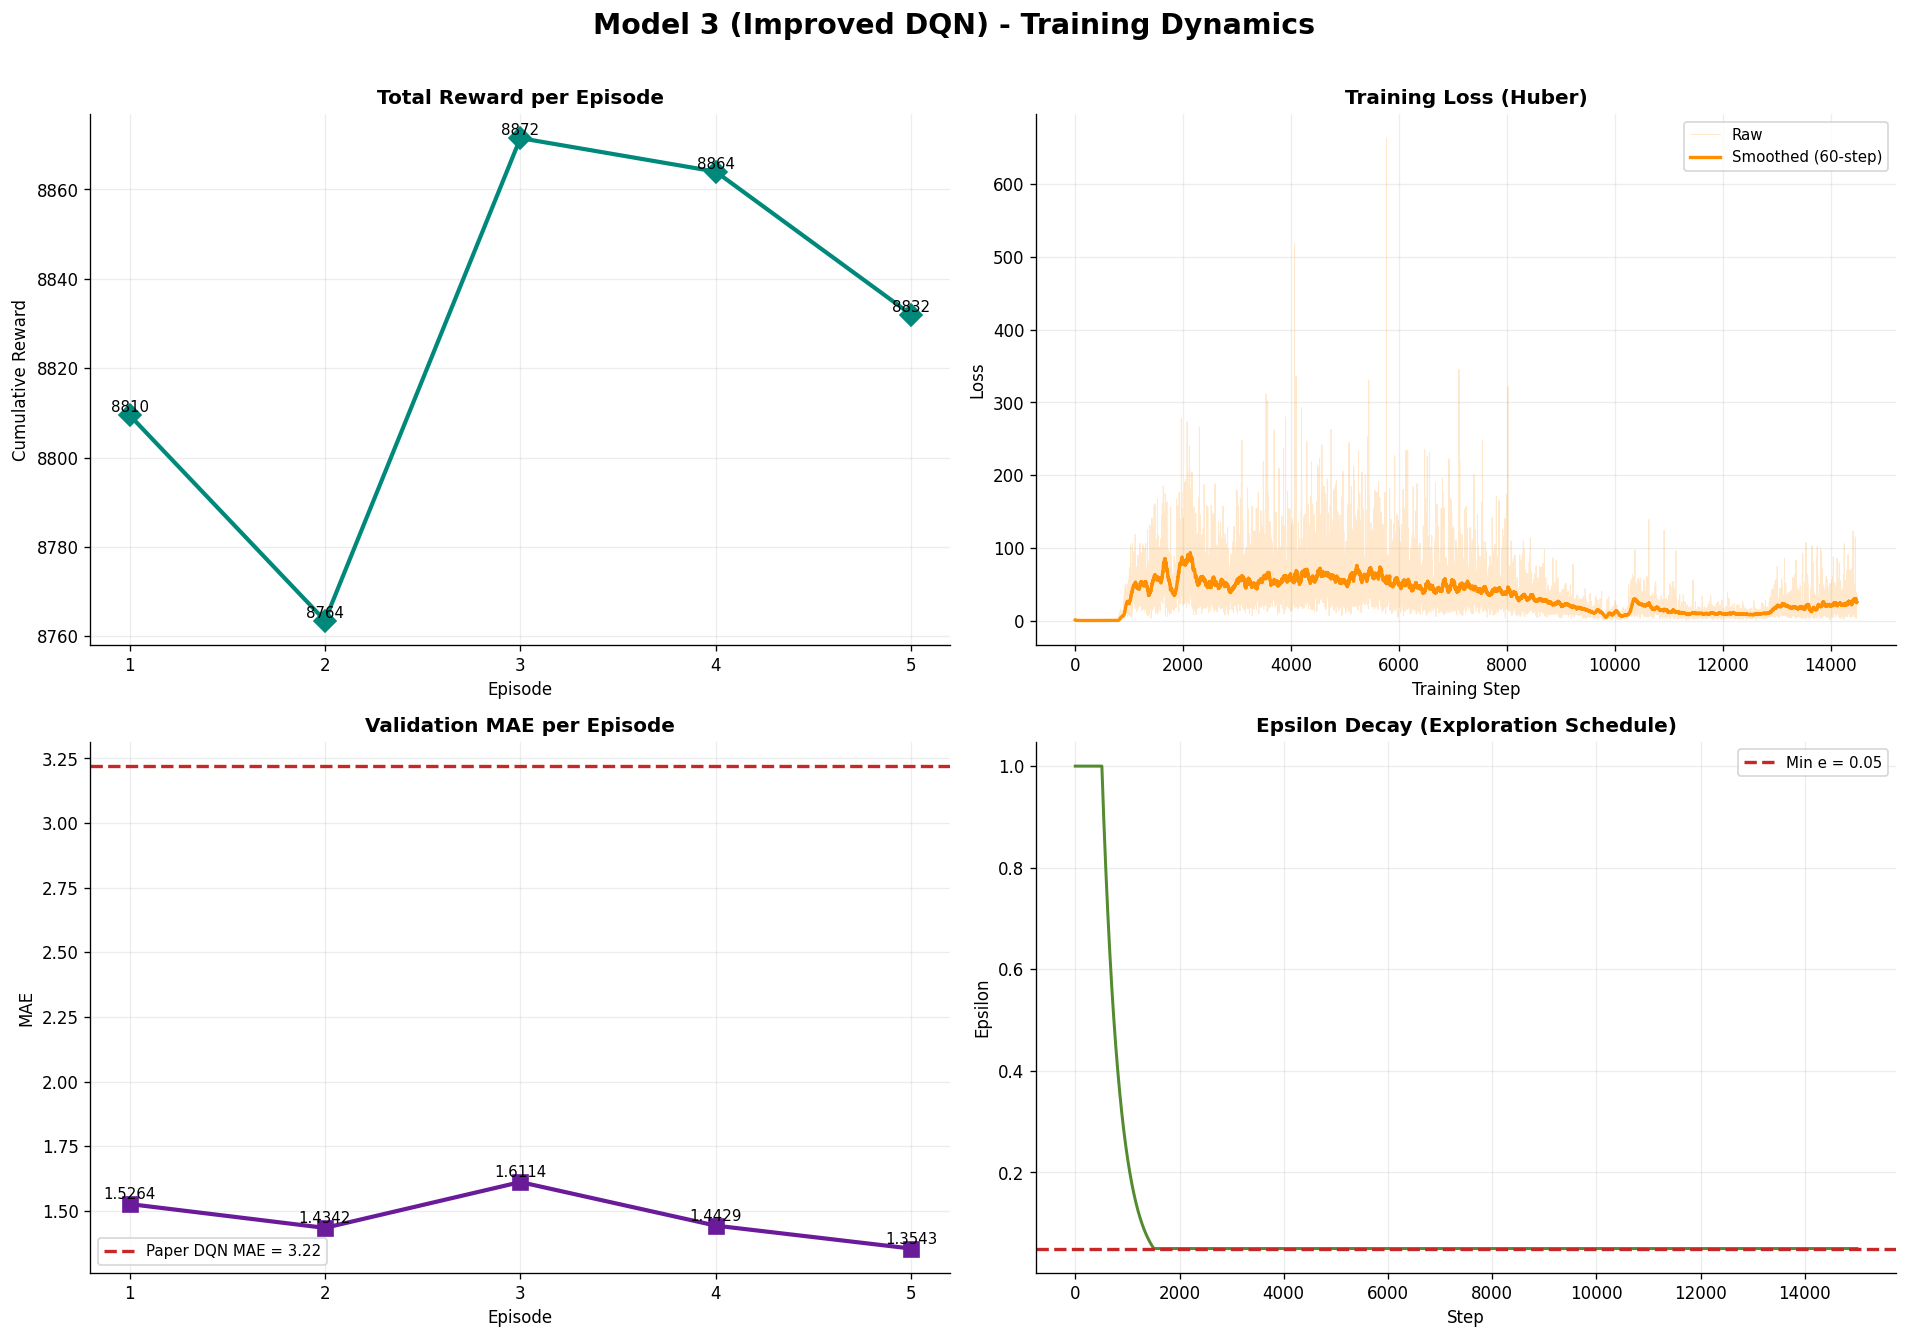

Saved: saved_models/dqn_training_dynamics.png


In [18]:
# PLOT 1 - Training Dynamics (4 subplots)
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('Model 3 (Improved DQN) - Training Dynamics', fontsize=17, fontweight='bold', y=1.01)

axes[0,0].plot(range(1,EPISODES+1), episode_rewards, color=C['teal'],
               linewidth=2.5, marker='D', markersize=9)
for i,r in enumerate(episode_rewards):
    axes[0,0].text(i+1, r, f'{r:.0f}', ha='center', va='bottom', fontsize=9)
axes[0,0].set_title('Total Reward per Episode', fontweight='bold')
axes[0,0].set_xlabel('Episode'); axes[0,0].set_ylabel('Cumulative Reward')
axes[0,0].set_xticks(range(1, EPISODES+1))

if all_losses:
    raw_s  = pd.Series(all_losses)
    smooth = raw_s.rolling(60, min_periods=1).mean()
    axes[0,1].plot(raw_s.values, color=C['amber'], alpha=0.2, linewidth=0.6, label='Raw')
    axes[0,1].plot(smooth.values, color=C['amber'], linewidth=2, label='Smoothed (60-step)')
    axes[0,1].set_title('Training Loss (Huber)', fontweight='bold')
    axes[0,1].set_xlabel('Training Step'); axes[0,1].set_ylabel('Loss')
    axes[0,1].legend(fontsize=9)

axes[1,0].plot(range(1,EPISODES+1), val_mae_history, color=C['violet'],
               linewidth=2.5, marker='s', markersize=9)
axes[1,0].axhline(3.22, color=C['rose'], linestyle='--', linewidth=2,
                   label='Paper DQN MAE = 3.22')
for i,v in enumerate(val_mae_history):
    axes[1,0].text(i+1, v+0.02, f'{v:.4f}', ha='center', fontsize=9)
axes[1,0].set_title('Validation MAE per Episode', fontweight='bold')
axes[1,0].set_xlabel('Episode'); axes[1,0].set_ylabel('MAE')
axes[1,0].set_xticks(range(1,EPISODES+1)); axes[1,0].legend(fontsize=9)

axes[1,1].plot(epsilon_history, color=C['lime'], linewidth=1.8)
axes[1,1].axhline(EPSILON_MIN, color=C['rose'], linestyle='--',
                   linewidth=2, label=f'Min e = {EPSILON_MIN}')
axes[1,1].set_title('Epsilon Decay (Exploration Schedule)', fontweight='bold')
axes[1,1].set_xlabel('Step'); axes[1,1].set_ylabel('Epsilon')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('saved_models/dqn_training_dynamics.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/dqn_training_dynamics.png')

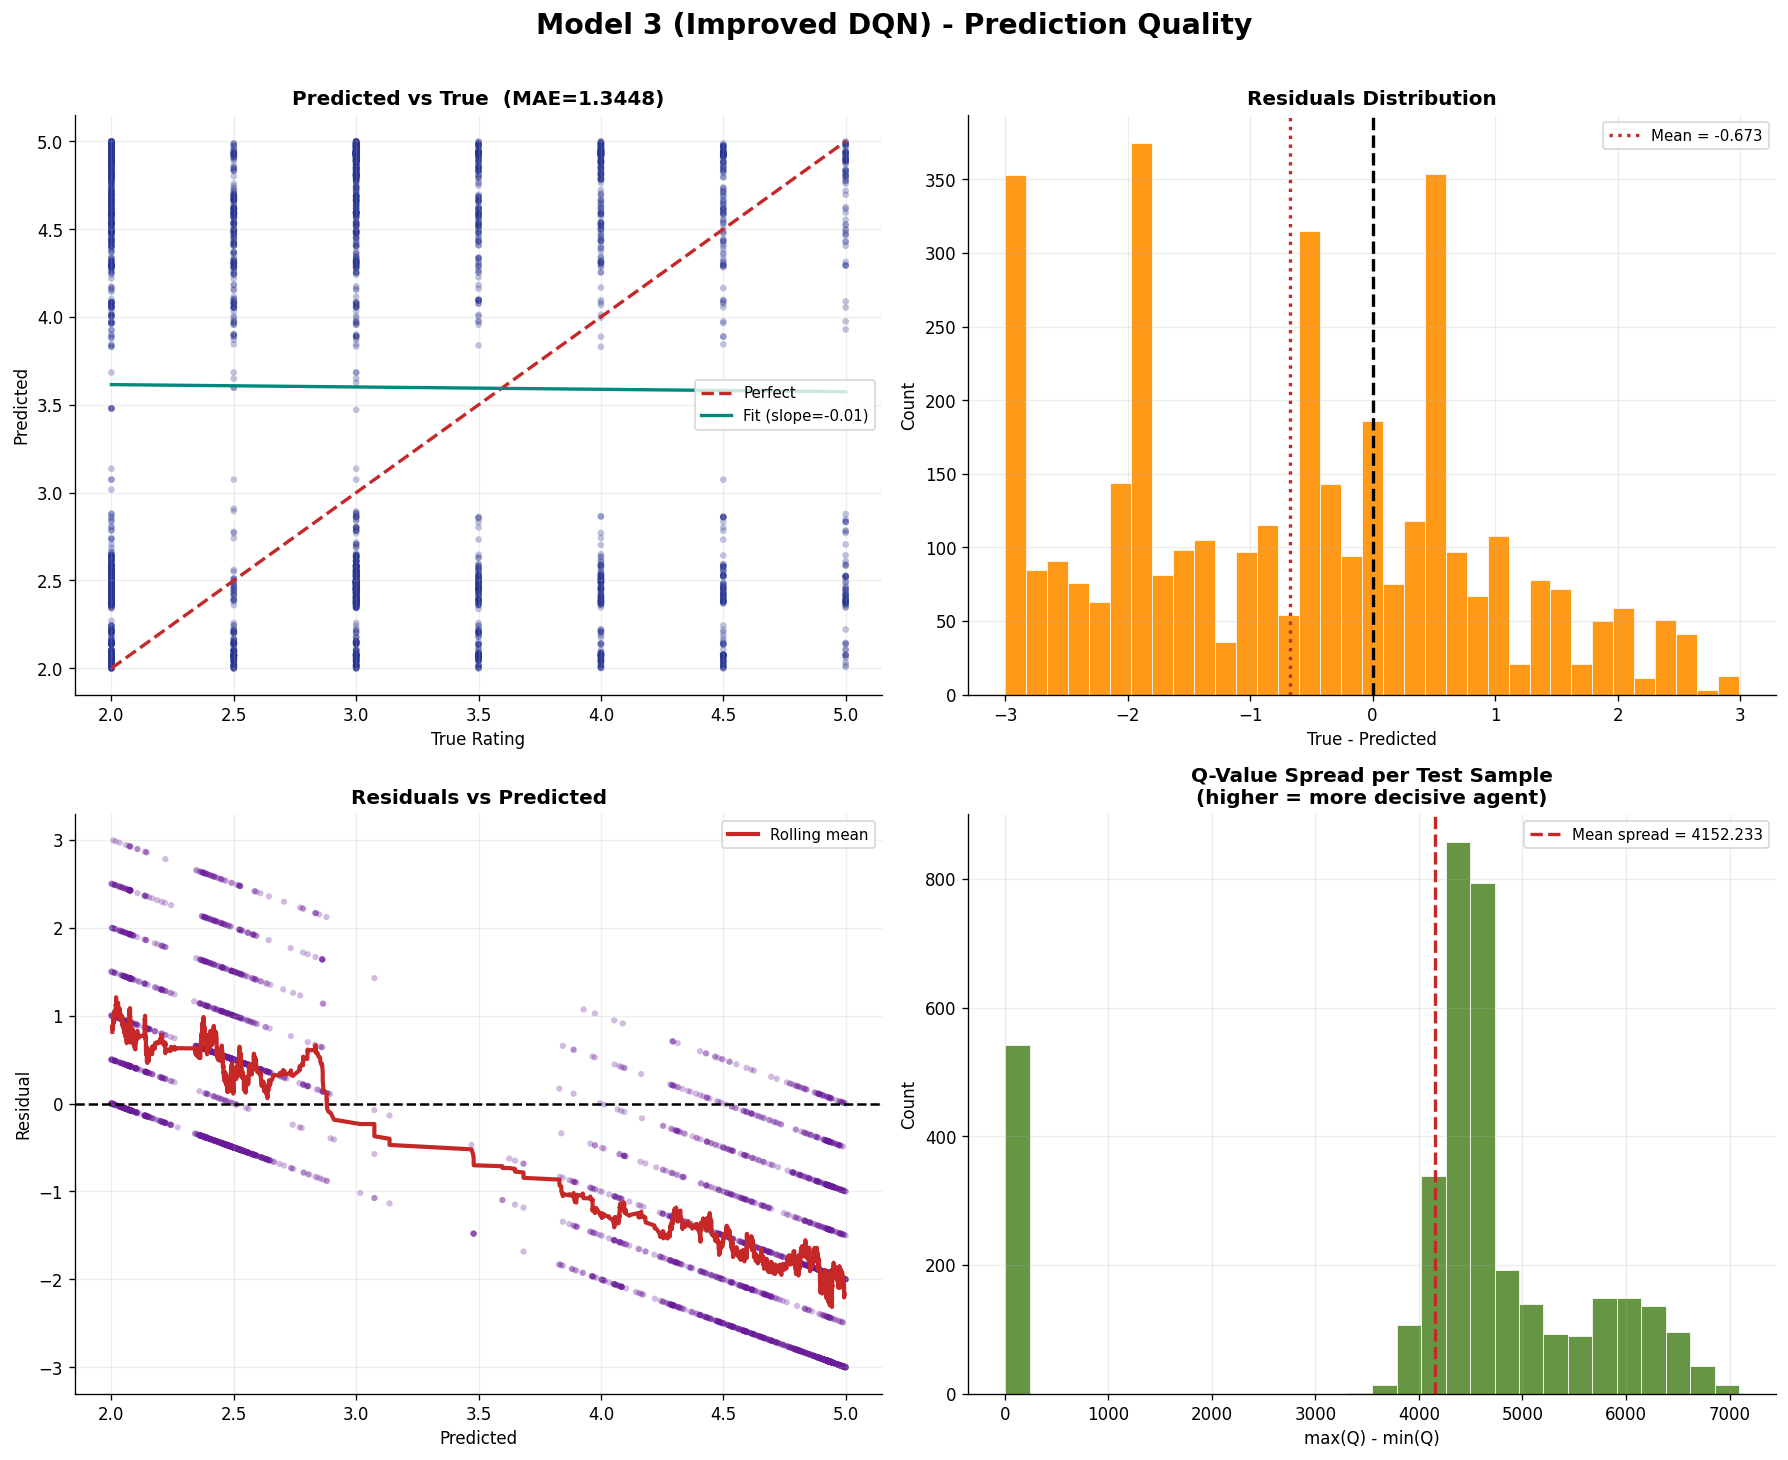

Saved: saved_models/dqn_prediction_quality.png


In [19]:
# PLOT 2 - Prediction Quality
errors = y_true_dqn - y_pred_dqn
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Model 3 (Improved DQN) - Prediction Quality', fontsize=17, fontweight='bold', y=1.01)

axes[0,0].scatter(y_true_dqn, y_pred_dqn, alpha=0.3, s=16, color=C['indigo'], edgecolors='none')
axes[0,0].plot([2,5],[2,5], linestyle='--', color=C['rose'], linewidth=2, label='Perfect')
m, b = np.polyfit(y_true_dqn, y_pred_dqn, 1)
xs = np.linspace(2, 5, 100)
axes[0,0].plot(xs, m*xs+b, color=C['teal'], linewidth=2, label=f'Fit (slope={m:.2f})')
axes[0,0].set_title(f'Predicted vs True  (MAE={mae_dqn:.4f})', fontweight='bold')
axes[0,0].set_xlabel('True Rating'); axes[0,0].set_ylabel('Predicted')
axes[0,0].legend(fontsize=9)

axes[0,1].hist(errors, bins=35, color=C['amber'], edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0,1].axvline(0, color='black', linewidth=2, linestyle='--')
axes[0,1].axvline(errors.mean(), color=C['rose'], linewidth=2,
                   linestyle=':', label=f'Mean = {errors.mean():.3f}')
axes[0,1].set_title('Residuals Distribution', fontweight='bold')
axes[0,1].set_xlabel('True - Predicted'); axes[0,1].set_ylabel('Count')
axes[0,1].legend(fontsize=9)

si = np.argsort(y_pred_dqn)
rm = pd.Series(errors[si]).rolling(50, center=True).mean()
axes[1,0].scatter(y_pred_dqn, errors, alpha=0.3, s=14, color=C['violet'], edgecolors='none')
axes[1,0].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1,0].plot(y_pred_dqn[si], rm.values, color=C['rose'], linewidth=2.5, label='Rolling mean')
axes[1,0].set_title('Residuals vs Predicted', fontweight='bold')
axes[1,0].set_xlabel('Predicted'); axes[1,0].set_ylabel('Residual')
axes[1,0].legend(fontsize=9)

axes[1,1].hist(q_spread_list, bins=30, color=C['lime'], edgecolor='white', linewidth=0.5, alpha=0.9)
axes[1,1].axvline(np.mean(q_spread_list), color=C['rose'], linewidth=2, linestyle='--',
                   label=f'Mean spread = {np.mean(q_spread_list):.3f}')
axes[1,1].set_title('Q-Value Spread per Test Sample\n(higher = more decisive agent)', fontweight='bold')
axes[1,1].set_xlabel('max(Q) - min(Q)'); axes[1,1].set_ylabel('Count')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('saved_models/dqn_prediction_quality.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/dqn_prediction_quality.png')

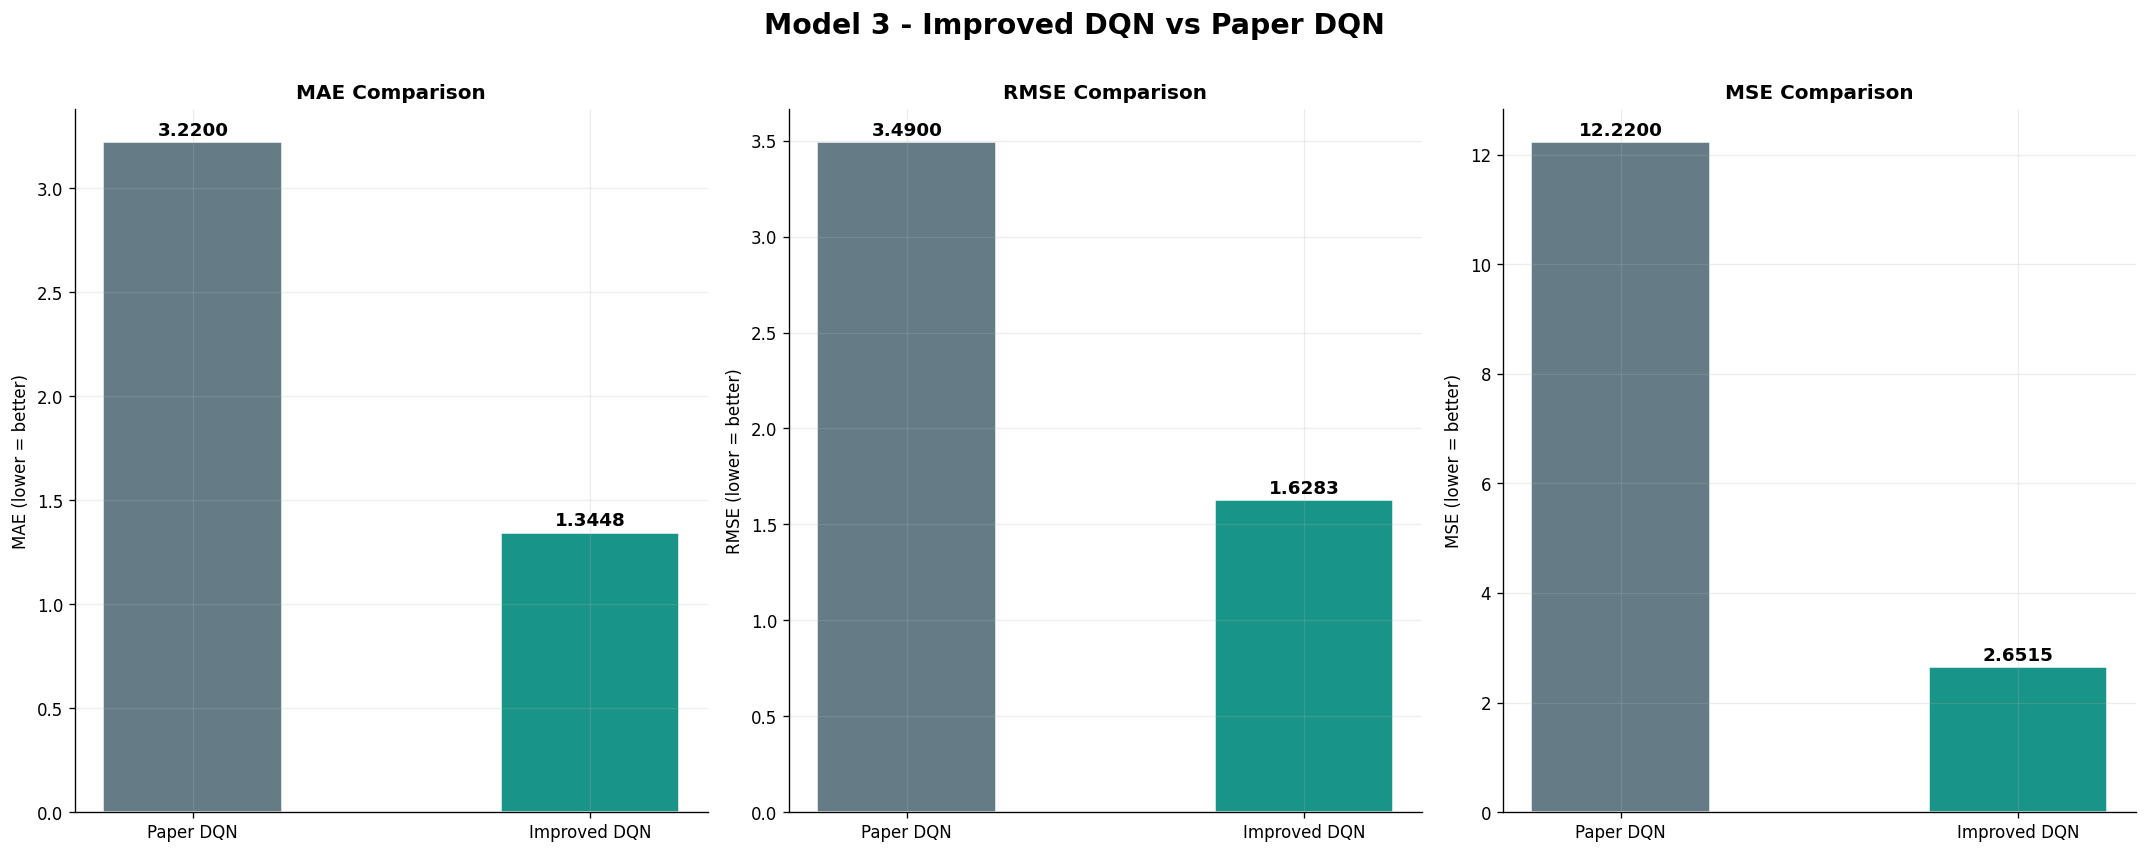

Saved: saved_models/dqn_vs_paper.png


In [20]:
# PLOT 3 - Model vs Paper Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Model 3 - Improved DQN vs Paper DQN', fontsize=17, fontweight='bold', y=1.01)
labels = ['Paper DQN', 'Improved DQN']
met_data = [('MAE', [3.22, mae_dqn]), ('RMSE', [3.49, rmse_dqn]), ('MSE', [12.22, mse_dqn])]
bar_clrs = [C['slate'], C['teal']]
for ax, (met, vals) in zip(axes, met_data):
    x = np.arange(len(labels))
    bars = ax.bar(x, vals, width=0.45, color=bar_clrs, edgecolor='white', alpha=0.9)
    ax.set_title(f'{met} Comparison', fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels(labels)
    ax.set_ylabel(f'{met} (lower = better)')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+max(vals)*0.01,
                f'{v:.4f}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('saved_models/dqn_vs_paper.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/dqn_vs_paper.png')

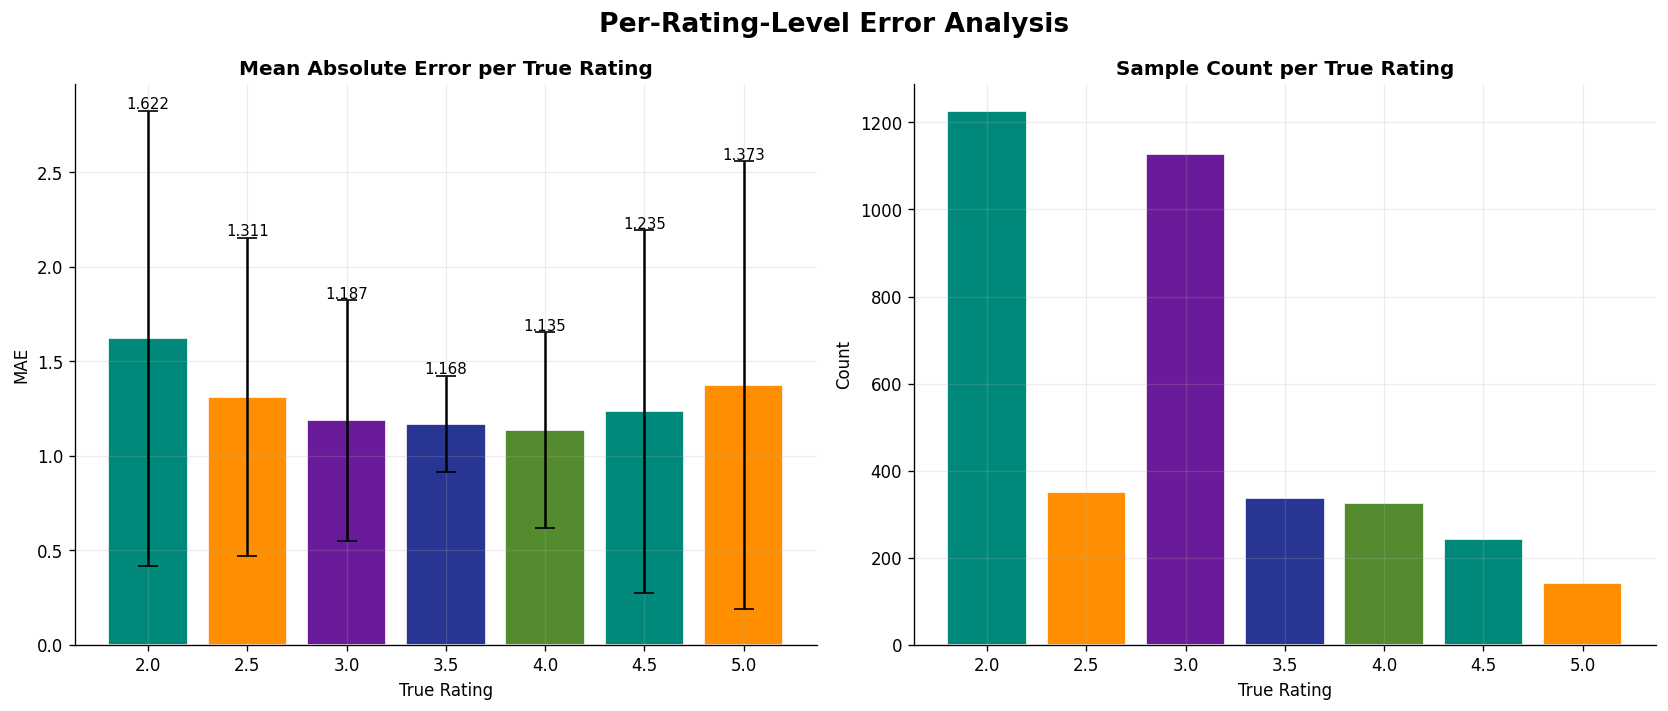

Saved: saved_models/dqn_per_rating_error.png
 true     mean      std  count
  2.0 1.621916 1.203442   1227
  2.5 1.311199 0.842001    351
  3.0 1.186802 0.637537   1127
  3.5 1.168350 0.254859    336
  4.0 1.135173 0.518527    325
  4.5 1.234757 0.959892    242
  5.0 1.372730 1.185921    142


In [21]:
# PLOT 4 - Per-Rating-Level Error Analysis
err_df    = pd.DataFrame({'true': y_true_dqn, 'pred': y_pred_dqn,
                           'abs_err': np.abs(errors)})
per_r     = err_df.groupby('true')['abs_err'].agg(['mean','std','count']).reset_index()
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Per-Rating-Level Error Analysis', fontsize=16, fontweight='bold')
clrs_pr = [C['teal'],C['amber'],C['violet'],C['indigo'],C['lime']]
bars = axes[0].bar(per_r['true'].astype(str), per_r['mean'],
                    yerr=per_r['std'], color=clrs_pr[:len(per_r)],
                    edgecolor='white', capsize=6)
axes[0].set_title('Mean Absolute Error per True Rating', fontweight='bold')
axes[0].set_xlabel('True Rating'); axes[0].set_ylabel('MAE')
for bar, (_, row) in zip(bars, per_r.iterrows()):
    axes[0].text(bar.get_x()+bar.get_width()/2,
                 bar.get_height()+row['std']+0.01,
                 f'{row["mean"]:.3f}', ha='center', fontsize=9)
axes[1].bar(per_r['true'].astype(str), per_r['count'],
             color=clrs_pr[:len(per_r)], edgecolor='white')
axes[1].set_title('Sample Count per True Rating', fontweight='bold')
axes[1].set_xlabel('True Rating'); axes[1].set_ylabel('Count')
plt.tight_layout()
plt.savefig('saved_models/dqn_per_rating_error.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/dqn_per_rating_error.png')
print(per_r.to_string(index=False))

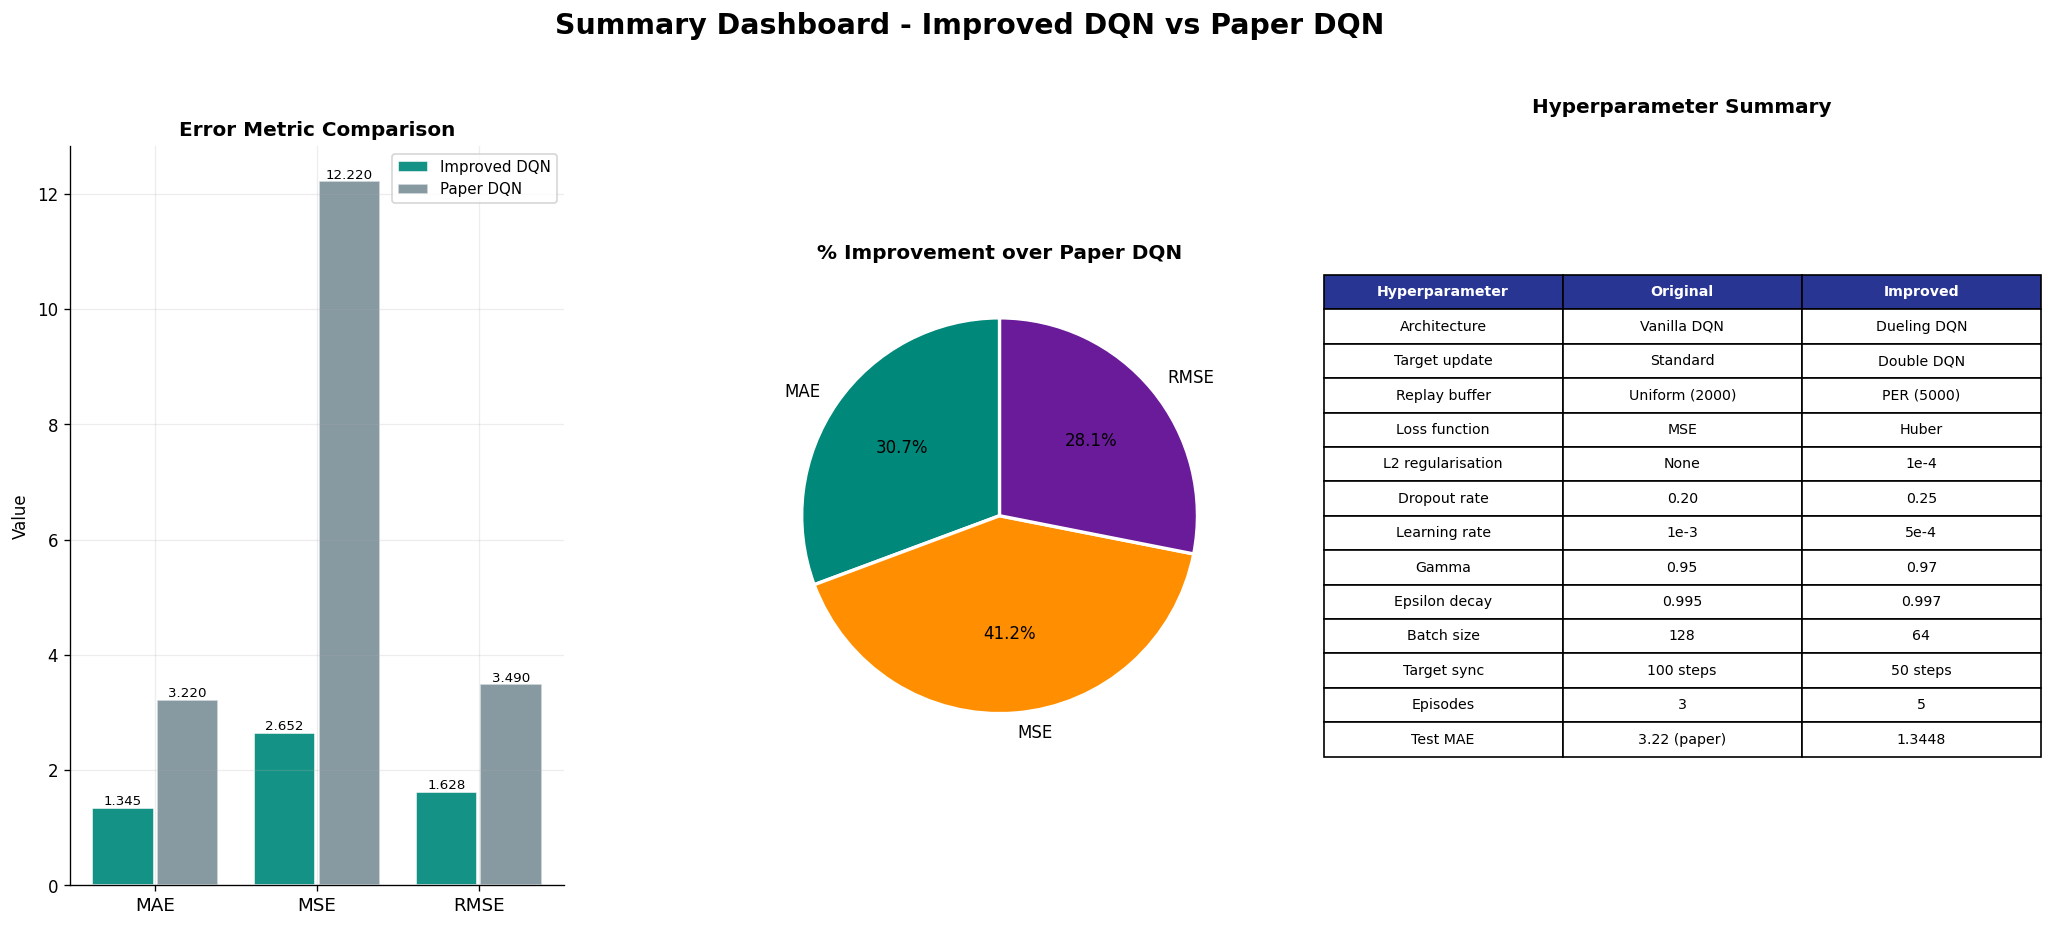

Saved: saved_models/dqn_summary_dashboard.png


In [22]:
# PLOT 5 - Summary Dashboard
fig = plt.figure(figsize=(20, 8))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)
fig.suptitle('Summary Dashboard - Improved DQN vs Paper DQN',
             fontsize=17, fontweight='bold', y=1.02)

ax1 = fig.add_subplot(gs[0,0])
met_names  = ['MAE','MSE','RMSE']
our_v      = [mae_dqn, mse_dqn, rmse_dqn]
paper_v    = [3.22, 12.22, 3.49]
x = np.arange(len(met_names))
ax1.bar(x-0.2, our_v,   0.38, color=C['teal'],  label='Improved DQN', edgecolor='white', alpha=0.92)
ax1.bar(x+0.2, paper_v, 0.38, color=C['slate'], label='Paper DQN',    edgecolor='white', alpha=0.70)
ax1.set_xticks(x); ax1.set_xticklabels(met_names, fontsize=11)
ax1.set_title('Error Metric Comparison', fontweight='bold')
ax1.set_ylabel('Value'); ax1.legend(fontsize=9)
for i,(o,p) in enumerate(zip(our_v, paper_v)):
    ax1.text(i-0.2, o+0.05, f'{o:.3f}', ha='center', fontsize=8)
    ax1.text(i+0.2, p+0.05, f'{p:.3f}', ha='center', fontsize=8)

ax2 = fig.add_subplot(gs[0,1])
impr    = [max(0,(p-o)/p*100) for o,p in zip(our_v, paper_v)]
pie_c   = [C['teal'], C['amber'], C['violet']]
wedges, texts, autotexts = ax2.pie(
    impr, labels=met_names, colors=pie_c,
    autopct='%1.1f%%', startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2))
ax2.set_title('% Improvement over Paper DQN', fontweight='bold')

ax3 = fig.add_subplot(gs[0,2])
ax3.axis('off')
tbl_data = [
    ['Hyperparameter',     'Original',       'Improved'],
    ['Architecture',       'Vanilla DQN',    'Dueling DQN'],
    ['Target update',      'Standard',       'Double DQN'],
    ['Replay buffer',      'Uniform (2000)', 'PER (5000)'],
    ['Loss function',      'MSE',            'Huber'],
    ['L2 regularisation',  'None',           '1e-4'],
    ['Dropout rate',       '0.20',           '0.25'],
    ['Learning rate',      '1e-3',           '5e-4'],
    ['Gamma',              '0.95',           '0.97'],
    ['Epsilon decay',      '0.995',          '0.997'],
    ['Batch size',         '128',            '64'],
    ['Target sync',        '100 steps',      '50 steps'],
    ['Episodes',           '3',              '5'],
    ['Test MAE',           '3.22 (paper)',   f'{mae_dqn:.4f}'],
]
tbl = ax3.table(cellText=tbl_data[1:], colLabels=tbl_data[0],
                 loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.45, 1.72)
for col in range(3):
    tbl[0,col].set_facecolor(C['indigo'])
    tbl[0,col].set_text_props(color='white', fontweight='bold')
ax3.set_title('Hyperparameter Summary', fontweight='bold', pad=20)

plt.savefig('saved_models/dqn_summary_dashboard.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: saved_models/dqn_summary_dashboard.png')

In [23]:
print('\n' + '='*65)
print('  FINAL SUMMARY - MODEL 3 (IMPROVED DQN)')
print('='*65)
print(f'  Architecture     : Dueling DQN + Double DQN + PER')
print(f'  Episodes         : {EPISODES}')
print(f'  Total steps      : {step:,}')
print(f'  Training time    : {str(timedelta(seconds=int(training_time_dqn)))}')
print(f'  Final epsilon    : {EPSILON:.4f}')
print(f'  Avg reward/ep    : {np.mean(episode_rewards):.2f}')
print(f'  Val MAE (ep)     : {[round(v,4) for v in val_mae_history]}')
print(f'  Test MAE         : {mae_dqn:.4f}  (paper: 3.22)')
print(f'  Test MSE         : {mse_dqn:.4f} (paper: 12.22)')
print(f'  Test RMSE        : {rmse_dqn:.4f}  (paper: 3.49)')
print(f'  Beats paper?     : {"YES" if mae_dqn < 3.22 else "NO"}')
print('='*65)
print('\nAll saved graphs:')
for fn in ['eda_ratings_overview.png','eda_user_preferences.png',
           'eda_user_presentation_types.png','eda_temporal.png',
           'dqn_training_dynamics.png','dqn_prediction_quality.png',
           'dqn_vs_paper.png','dqn_per_rating_error.png','dqn_summary_dashboard.png']:
    print(f'  saved_models/{fn}')


  FINAL SUMMARY - MODEL 3 (IMPROVED DQN)
  Architecture     : Dueling DQN + Double DQN + PER
  Episodes         : 5
  Total steps      : 15,000
  Training time    : 0:13:35
  Final epsilon    : 0.0500
  Avg reward/ep    : 8828.10
  Val MAE (ep)     : [1.5264, 1.4342, 1.6114, 1.4429, 1.3543]
  Test MAE         : 1.3448  (paper: 3.22)
  Test MSE         : 2.6515 (paper: 12.22)
  Test RMSE        : 1.6283  (paper: 3.49)
  Beats paper?     : YES

All saved graphs:
  saved_models/eda_ratings_overview.png
  saved_models/eda_user_preferences.png
  saved_models/eda_user_presentation_types.png
  saved_models/eda_temporal.png
  saved_models/dqn_training_dynamics.png
  saved_models/dqn_prediction_quality.png
  saved_models/dqn_vs_paper.png
  saved_models/dqn_per_rating_error.png
  saved_models/dqn_summary_dashboard.png
